# 02 Short-Horizon Qualifying Modeling

Scalony notebook dla kwalifikacji 2023-2025: baseline, walidacja grupowana, redukcja kierowcow, tuning, interpretacja i pierwsze modele sekwencyjne.


## Source: `05_baseline_driver_classification.ipynb`


# 05 Baseline Driver Classification

This notebook trains the first supervised baselines for driver identification from lap-level handcrafted telemetry features.

It runs two experiments:

- **Experiment A** keeps lap-time-related variables.
- **Experiment B** removes lap-time and sector-time variables, plus deterministic derivatives of those timings, to test whether broader style information remains.

The workflow is export-friendly: every main result is written to `exports/` as CSV for external verification.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(df: pd.DataFrame, feature_cols, scale_numeric: bool) -> ColumnTransformer:
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )

def build_model_specs(df: pd.DataFrame, feature_cols):
    linear_preprocessor = build_preprocessor(df, feature_cols, scale_numeric=True)
    tree_preprocessor = build_preprocessor(df, feature_cols, scale_numeric=False)

    model_specs = {
        "logistic_regression": Pipeline(
            steps=[
                ("preprocess", linear_preprocessor),
                ("model", LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)),
            ]
        ),
        "random_forest": Pipeline(
            steps=[
                ("preprocess", tree_preprocessor),
                ("model", RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)),
            ]
        ),
        "hist_gradient_boosting": Pipeline(
            steps=[
                ("preprocess", tree_preprocessor),
                ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
            ]
        ),
    }

    if XGBOOST_AVAILABLE:
        model_specs["xgboost"] = Pipeline(
            steps=[
                ("preprocess", tree_preprocessor),
                (
                    "model",
                    XGBClassifier(
                        objective="multi:softprob",
                        eval_metric="mlogloss",
                        n_estimators=400,
                        learning_rate=0.05,
                        max_depth=6,
                        subsample=0.9,
                        colsample_bytree=0.9,
                        random_state=RANDOM_STATE,
                        tree_method="hist",
                    ),
                ),
            ]
        )

    return model_specs

def extract_feature_importance(fitted_pipeline: Pipeline, experiment_name: str, model_name: str):
    model = fitted_pipeline.named_steps["model"]
    preprocessor = fitted_pipeline.named_steps["preprocess"]

    if not hasattr(preprocessor, "get_feature_names_out"):
        return None

    feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "coef_"):
        importance_values = np.abs(model.coef_).mean(axis=0)
        importance_type = "mean_abs_coef"
    elif hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
        importance_type = "feature_importance"
    else:
        return None

    return pd.DataFrame(
        {
            "experiment": experiment_name,
            "model": model_name,
            "importance_type": importance_type,
            "feature": feature_names,
            "importance": importance_values,
        }
    ).sort_values("importance", ascending=False)

def evaluate_experiment(df: pd.DataFrame, experiment_name: str, feature_cols, target_col: str):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    labels = sorted(y.unique())
    cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    model_specs = build_model_specs(df, feature_cols)

    fold_rows = []
    summary_rows = []
    oof_frames = []
    confusion_frames = []
    importance_frames = []

    for model_name, estimator in model_specs.items():
        oof_pred = pd.Series(index=y.index, dtype="object")

        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
            fitted_estimator = clone(estimator)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]

            if model_name == "xgboost":
                label_encoder = LabelEncoder()
                y_train_encoded = label_encoder.fit_transform(y_train)
                fitted_estimator.fit(X_train, y_train_encoded)
                y_pred_encoded = fitted_estimator.predict(X_test)
                y_pred = label_encoder.inverse_transform(np.asarray(y_pred_encoded).astype(int))
            else:
                fitted_estimator.fit(X_train, y_train)
                y_pred = fitted_estimator.predict(X_test)
            oof_pred.iloc[test_idx] = y_pred

            fold_rows.append(
                {
                    "experiment": experiment_name,
                    "model": model_name,
                    "fold": fold_idx,
                    "n_train": len(train_idx),
                    "n_test": len(test_idx),
                    "accuracy": accuracy_score(y_test, y_pred),
                    "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
                    "macro_f1": f1_score(y_test, y_pred, average="macro"),
                }
            )

        oof_df = pd.DataFrame(
            {
                "lap_key": df["lap_key"],
                "experiment": experiment_name,
                "model": model_name,
                "true_driver": y,
                "pred_driver": oof_pred,
            }
        )
        oof_frames.append(oof_df)

        confusion = confusion_matrix(y, oof_pred, labels=labels)
        confusion_df = pd.DataFrame(confusion, index=labels, columns=labels)
        confusion_long = confusion_df.stack().reset_index()
        confusion_long.columns = ["true_driver", "pred_driver", "count"]
        confusion_long.insert(0, "model", model_name)
        confusion_long.insert(0, "experiment", experiment_name)
        confusion_frames.append(confusion_long)

        fold_df = pd.DataFrame(fold_rows)
        model_fold_df = fold_df[(fold_df["experiment"] == experiment_name) & (fold_df["model"] == model_name)].copy()

        summary_rows.append(
            {
                "experiment": experiment_name,
                "model": model_name,
                "n_features": len(feature_cols),
                "cv_accuracy_mean": model_fold_df["accuracy"].mean(),
                "cv_accuracy_std": model_fold_df["accuracy"].std(),
                "cv_balanced_accuracy_mean": model_fold_df["balanced_accuracy"].mean(),
                "cv_balanced_accuracy_std": model_fold_df["balanced_accuracy"].std(),
                "cv_macro_f1_mean": model_fold_df["macro_f1"].mean(),
                "cv_macro_f1_std": model_fold_df["macro_f1"].std(),
                "oof_accuracy": accuracy_score(y, oof_pred),
                "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
                "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
            }
        )

        fitted_full = clone(estimator)
        if model_name == "xgboost":
            full_label_encoder = LabelEncoder()
            y_full_encoded = full_label_encoder.fit_transform(y)
            fitted_full.fit(X, y_full_encoded)
        else:
            fitted_full.fit(X, y)
        importance_df = extract_feature_importance(fitted_full, experiment_name, model_name)
        if importance_df is not None:
            importance_frames.append(importance_df)

    fold_metrics_df = pd.DataFrame(fold_rows)
    summary_df = pd.DataFrame(summary_rows).sort_values(["experiment", "oof_macro_f1", "cv_macro_f1_mean"], ascending=[True, False, False])
    oof_predictions_df = pd.concat(oof_frames, ignore_index=True)
    confusion_df = pd.concat(confusion_frames, ignore_index=True)
    if importance_frames:
        importance_df = pd.concat(importance_frames, ignore_index=True)
    else:
        importance_df = pd.DataFrame(columns=["experiment", "model", "importance_type", "feature", "importance"])

    return fold_metrics_df, summary_df, oof_predictions_df, confusion_df, importance_df

## Modeling Assumptions

- The prediction target is `Driver`.
- The following are excluded from all experiments to reduce obvious leakage or session metadata effects: `lap_key`, `Driver`, `season`, `round`, `LapNumber`, `Team`.
- Weak or constant features already identified in the exported feature tables are dropped from all experiments: `throttle_min`, `brake_min`, `brake_median`, `brake_hard_frac`, `drs_toggle_count`, `brake_diff_mean`, `drs_active_frac`.
- Experiment B also removes direct lap-time variables and their deterministic derivatives: `LapTimeSeconds`, sector times, `sector_sum_seconds`, and sector share variables.
- `Compound` is retained as a categorical feature; `TyreLife` is retained as numeric.

In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
missingness_df = pd.read_csv(EXPORT_DIR / "lap_features_missingness.csv")
class_balance_df = pd.read_csv(EXPORT_DIR / "lap_features_model_class_balance.csv")

TARGET_COL = "Driver"
BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
]
TIME_EXCLUDED_COLS = [
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]

experiment_feature_sets = {
    "experiment_a_with_time_features": [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS],
    "experiment_b_without_time_features": [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS + TIME_EXCLUDED_COLS],
}

feature_inventory_rows = []
for experiment_name, feature_cols in experiment_feature_sets.items():
    for feature_name in feature_cols:
        feature_inventory_rows.append(
            {
                "experiment": experiment_name,
                "feature": feature_name,
                "dtype": str(features_df[feature_name].dtype),
                "missing_fraction": features_df[feature_name].isna().mean(),
            }
        )

feature_inventory_df = pd.DataFrame(feature_inventory_rows).sort_values(["experiment", "feature"])
export_csv(feature_inventory_df, "baseline_feature_inventory")

print(f"Dataset shape: {features_df.shape}")
print(f"Drivers: {features_df[TARGET_COL].nunique()}")
print(f"Stratified folds: {N_SPLITS}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
print()
print("Class balance:")
display(class_balance_df)
print("Feature counts by experiment:")
display(feature_inventory_df.groupby("experiment")["feature"].count().rename("n_features").reset_index())
print("Highest missingness from the exported feature table:")
display(missingness_df.head(10))

Dataset shape: (766, 85)
Drivers: 14
Stratified folds: 5
XGBoost available: True

Class balance:


,Driver,n_laps
0,ALB,55
1,ALO,55
2,GAS,55
3,HAM,55
4,HUL,55
5,LEC,55
6,NOR,55
7,PIA,55
8,RUS,55
9,VER,55


Feature counts by experiment:


,experiment,n_features
0,experiment_a_with_time_features,72
1,experiment_b_without_time_features,64


Highest missingness from the exported feature table:


,column,missing_fraction
0,TyreLife,0.001833
1,Compound,0.001833
2,last_full_throttle_frac_pos,0.001833
3,first_brake_frac_pos,0.001833
4,last_brake_frac_pos,0.001833
5,first_full_throttle_frac_pos,0.001833
6,speed_cv,0.001833
7,rpm_cv,0.001833
8,Driver,0.000000
9,LapNumber,0.000000


In [4]:
all_fold_metrics = []
all_summaries = []
all_oof_predictions = []
all_confusion = []
all_importance = []

for experiment_name, feature_cols in experiment_feature_sets.items():
    print(f"Running {experiment_name} with {len(feature_cols)} features...")
    fold_metrics_df, summary_df, oof_predictions_df, confusion_df, importance_df = evaluate_experiment(
        features_df,
        experiment_name=experiment_name,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
    )
    all_fold_metrics.append(fold_metrics_df)
    all_summaries.append(summary_df)
    all_oof_predictions.append(oof_predictions_df)
    all_confusion.append(confusion_df)
    all_importance.append(importance_df)

baseline_cv_fold_metrics_df = pd.concat(all_fold_metrics, ignore_index=True)
baseline_model_summary_df = pd.concat(all_summaries, ignore_index=True)
baseline_oof_predictions_df = pd.concat(all_oof_predictions, ignore_index=True)
baseline_confusion_matrix_df = pd.concat(all_confusion, ignore_index=True)
baseline_feature_importance_df = pd.concat(all_importance, ignore_index=True)

best_models_df = (
    baseline_model_summary_df.sort_values(["experiment", "oof_macro_f1", "cv_macro_f1_mean"], ascending=[True, False, False])
    .groupby("experiment", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

export_csv(baseline_cv_fold_metrics_df, "baseline_cv_fold_metrics")
export_csv(baseline_model_summary_df, "baseline_model_summary")
export_csv(best_models_df, "baseline_best_models")
export_csv(baseline_oof_predictions_df, "baseline_oof_predictions")
export_csv(baseline_confusion_matrix_df, "baseline_confusion_matrix")
export_csv(baseline_feature_importance_df, "baseline_feature_importance")

print("Exported:")
print("- exports/baseline_feature_inventory.csv")
print("- exports/baseline_cv_fold_metrics.csv")
print("- exports/baseline_model_summary.csv")
print("- exports/baseline_best_models.csv")
print("- exports/baseline_oof_predictions.csv")
print("- exports/baseline_confusion_matrix.csv")
print("- exports/baseline_feature_importance.csv")

Running experiment_a_with_time_features with 72 features...


Running experiment_b_without_time_features with 64 features...


Exported:
- exports/baseline_feature_inventory.csv
- exports/baseline_cv_fold_metrics.csv
- exports/baseline_model_summary.csv
- exports/baseline_best_models.csv
- exports/baseline_oof_predictions.csv
- exports/baseline_confusion_matrix.csv
- exports/baseline_feature_importance.csv


,experiment,model,n_features,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,experiment_a_with_time_features,logistic_regression,72,0.608276,0.039494,0.608312,0.039197,0.600264,0.034188,0.608355,0.608538,0.605626
1,experiment_a_with_time_features,hist_gradient_boosting,72,0.400696,0.042290,0.401039,0.041491,0.395514,0.034728,0.400783,0.400842,0.398667
2,experiment_a_with_time_features,xgboost,72,0.383762,0.041040,0.383766,0.039597,0.376016,0.034166,0.383812,0.383886,0.381851
3,experiment_a_with_time_features,random_forest,72,0.347229,0.065040,0.348312,0.064269,0.333787,0.059911,0.347258,0.347715,0.337707
4,experiment_b_without_time_features,logistic_regression,64,0.617418,0.036224,0.617403,0.036185,0.610323,0.029843,0.617493,0.617677,0.615982
5,experiment_b_without_time_features,hist_gradient_boosting,64,0.412478,0.031478,0.412857,0.030233,0.406179,0.022910,0.412533,0.412506,0.411034
6,experiment_b_without_time_features,xgboost,64,0.405950,0.038787,0.406104,0.037188,0.398044,0.031577,0.406005,0.406037,0.404475
7,experiment_b_without_time_features,random_forest,64,0.352449,0.036552,0.353636,0.035417,0.337088,0.031461,0.352480,0.353054,0.341630


,experiment,model,n_features,cv_accuracy_mean,cv_accuracy_std,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,experiment_a_with_time_features,logistic_regression,72,0.608276,0.039494,0.608312,0.039197,0.600264,0.034188,0.608355,0.608538,0.605626
1,experiment_b_without_time_features,logistic_regression,64,0.617418,0.036224,0.617403,0.036185,0.610323,0.029843,0.617493,0.617677,0.615982


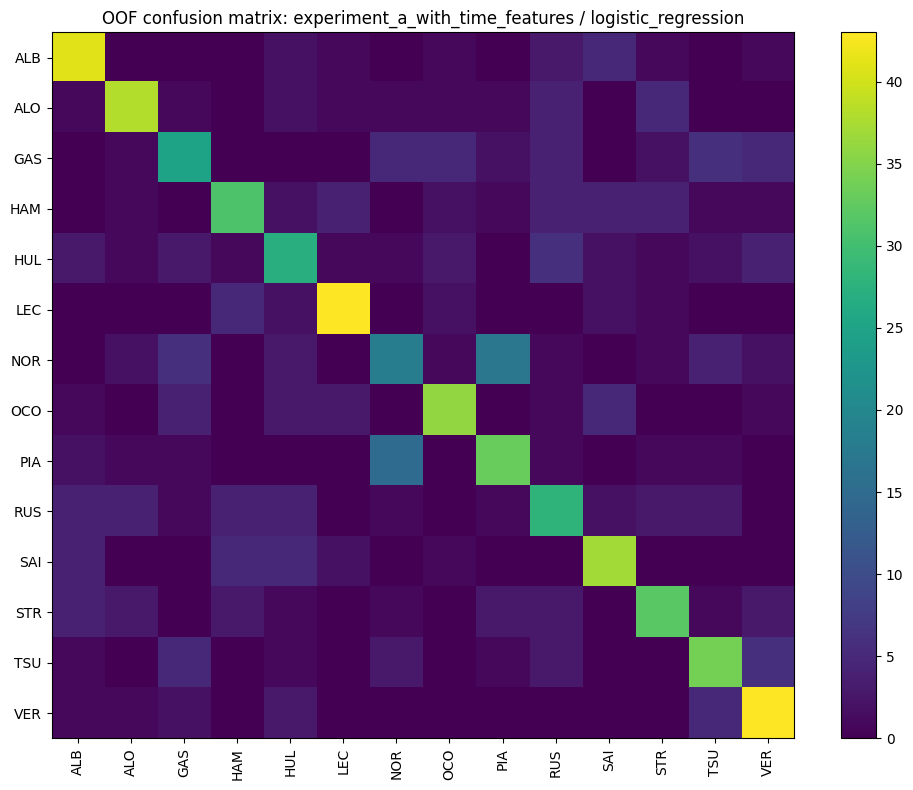

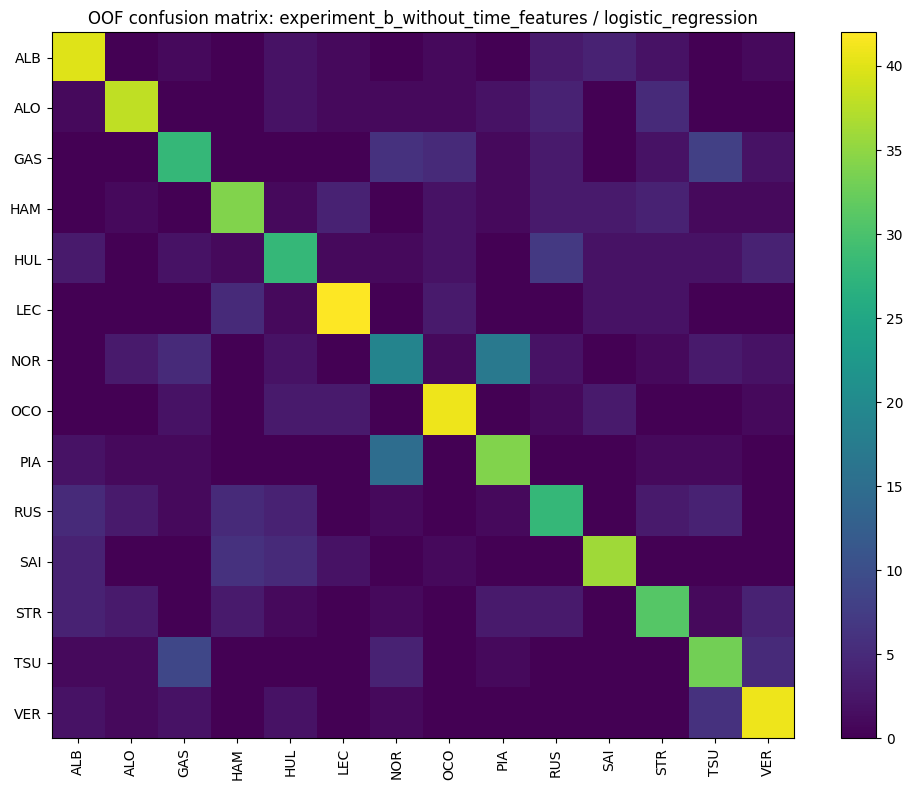

,experiment,model,importance_type,feature,importance
0,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__gear_mean,1.220672
1,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__gear_std,1.173742
2,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_zero_frac,1.128563
3,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_full_frac,1.031280
4,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_mid_frac,0.974037
...,...,...,...,...,...
364,experiment_b_without_time_features,xgboost,feature_importance,num__brake_std,0.021308
365,experiment_b_without_time_features,xgboost,feature_importance,cat__Compound_SOFT,0.021261
366,experiment_b_without_time_features,xgboost,feature_importance,num__rpm_diff_abs_mean,0.018815
367,experiment_b_without_time_features,xgboost,feature_importance,num__throttle_mid_frac,0.018501


In [5]:
display(baseline_model_summary_df.sort_values(["experiment", "oof_macro_f1", "cv_macro_f1_mean"], ascending=[True, False, False]))
display(best_models_df)

for _, row in best_models_df.iterrows():
    experiment_name = row["experiment"]
    model_name = row["model"]
    subset = baseline_confusion_matrix_df[
        (baseline_confusion_matrix_df["experiment"] == experiment_name)
        & (baseline_confusion_matrix_df["model"] == model_name)
    ].copy()
    confusion_table = subset.pivot(index="true_driver", columns="pred_driver", values="count").fillna(0)

    plt.figure(figsize=(10, 8))
    plt.imshow(confusion_table, aspect="auto")
    plt.title(f"OOF confusion matrix: {experiment_name} / {model_name}")
    plt.xticks(range(len(confusion_table.columns)), confusion_table.columns, rotation=90)
    plt.yticks(range(len(confusion_table.index)), confusion_table.index)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

top_importance_df = (
    baseline_feature_importance_df.sort_values(["experiment", "model", "importance"], ascending=[True, True, False])
    .groupby(["experiment", "model"], as_index=False)
    .head(15)
)
display(top_importance_df)

## Suggested Next Step

If the cross-validated baselines show meaningful signal, the next analysis notebook can compare those handcrafted-feature results with sequence-based models built directly from per-lap telemetry sequences.

## Source: `06_grouped_driver_classification_validation.ipynb`


# 06 Grouped Validation And Overfitting Check

This notebook hardens the first driver-classification baselines by evaluating them with session-level grouped cross-validation.

Why this matters:

- Random stratified folds can mix laps from the same qualifying session into both train and test sets.
- That can make the task easier because session-specific conditions remain partially shared.
- Grouped validation by qualifying session is stricter and better aligned with the thesis goal of learning driver style rather than memorizing session context.

This notebook also records train-vs-test gaps to check for overfitting.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBClassifier = None
    XGBOOST_AVAILABLE = False

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_preprocessor(df: pd.DataFrame, feature_cols, scale_numeric: bool) -> ColumnTransformer:
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    numeric_steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale_numeric:
        numeric_steps.append(("scaler", StandardScaler()))

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", make_one_hot_encoder()),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline(steps=numeric_steps), numeric_cols),
            ("cat", categorical_pipeline, categorical_cols),
        ],
        remainder="drop",
    )

def build_model_specs(df: pd.DataFrame, feature_cols):
    linear_preprocessor = build_preprocessor(df, feature_cols, scale_numeric=True)
    tree_preprocessor = build_preprocessor(df, feature_cols, scale_numeric=False)

    model_specs = {
        "logistic_regression": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocess", linear_preprocessor),
                    ("model", LogisticRegression(C=1.0, max_iter=5000, penalty="l2", solver="lbfgs", random_state=RANDOM_STATE)),
                ]
            ),
            "param_summary": {
                "C": 1.0,
                "penalty": "l2",
                "solver": "lbfgs",
                "max_iter": 5000,
            },
        },
        "random_forest": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocess", tree_preprocessor),
                    ("model", RandomForestClassifier(n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1)),
                ]
            ),
            "param_summary": {
                "n_estimators": 500,
                "max_depth": None,
                "min_samples_leaf": 1,
                "max_features": "sqrt",
            },
        },
        "hist_gradient_boosting": {
            "pipeline": Pipeline(
                steps=[
                    ("preprocess", tree_preprocessor),
                    ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
                ]
            ),
            "param_summary": {
                "learning_rate": 0.1,
                "max_depth": None,
                "max_leaf_nodes": 31,
                "min_samples_leaf": 20,
            },
        },
    }

    if XGBOOST_AVAILABLE:
        model_specs["xgboost"] = {
            "pipeline": Pipeline(
                steps=[
                    ("preprocess", tree_preprocessor),
                    (
                        "model",
                        XGBClassifier(
                            objective="multi:softprob",
                            eval_metric="mlogloss",
                            n_estimators=400,
                            learning_rate=0.05,
                            max_depth=6,
                            subsample=0.9,
                            colsample_bytree=0.9,
                            random_state=RANDOM_STATE,
                            tree_method="hist",
                        ),
                    ),
                ]
            ),
            "param_summary": {
                "n_estimators": 400,
                "learning_rate": 0.05,
                "max_depth": 6,
                "subsample": 0.9,
                "colsample_bytree": 0.9,
            },
        }

    return model_specs

def extract_feature_importance(fitted_pipeline: Pipeline, experiment_name: str, model_name: str):
    model = fitted_pipeline.named_steps["model"]
    preprocessor = fitted_pipeline.named_steps["preprocess"]

    if not hasattr(preprocessor, "get_feature_names_out"):
        return None

    feature_names = preprocessor.get_feature_names_out()

    if hasattr(model, "coef_"):
        importance_values = np.abs(model.coef_).mean(axis=0)
        importance_type = "mean_abs_coef"
    elif hasattr(model, "feature_importances_"):
        importance_values = model.feature_importances_
        importance_type = "feature_importance"
    else:
        return None

    return pd.DataFrame(
        {
            "experiment": experiment_name,
            "model": model_name,
            "importance_type": importance_type,
            "feature": feature_names,
            "importance": importance_values,
        }
    ).sort_values("importance", ascending=False)

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def fit_predict_with_optional_label_encoding(model_name, estimator, X_train, y_train, X_eval):
    if model_name == "xgboost":
        label_encoder = LabelEncoder()
        y_train_encoded = label_encoder.fit_transform(y_train)
        estimator.fit(X_train, y_train_encoded)
        pred_encoded = estimator.predict(X_eval)
        pred = label_encoder.inverse_transform(np.asarray(pred_encoded).astype(int))
        return estimator, pred

    estimator.fit(X_train, y_train)
    pred = estimator.predict(X_eval)
    return estimator, pred

def evaluate_grouped_experiment(df: pd.DataFrame, experiment_name: str, feature_cols, target_col: str, group_col: str):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    groups = df[group_col].copy()
    labels = sorted(y.unique())
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    model_specs = build_model_specs(df, feature_cols)

    fold_rows = []
    summary_rows = []
    oof_frames = []
    importance_frames = []
    config_rows = []

    for model_name, model_spec in model_specs.items():
        estimator = model_spec["pipeline"]
        param_summary = model_spec["param_summary"]
        oof_pred = pd.Series(index=y.index, dtype="object")

        config_rows.append(
            {
                "experiment": experiment_name,
                "model": model_name,
                **param_summary,
            }
        )

        for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
            fitted_estimator = clone(estimator)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]
            train_groups = groups.iloc[train_idx]
            test_groups = groups.iloc[test_idx]

            fitted_estimator, y_pred_test = fit_predict_with_optional_label_encoding(model_name, fitted_estimator, X_train, y_train, X_test)
            y_pred_train = fitted_estimator.predict(X_train)
            if model_name == "xgboost":
                label_encoder = LabelEncoder().fit(y_train)
                y_pred_train = label_encoder.inverse_transform(np.asarray(y_pred_train).astype(int))

            oof_pred.iloc[test_idx] = y_pred_test

            row = {
                "experiment": experiment_name,
                "model": model_name,
                "fold": fold_idx,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "train_groups": train_groups.nunique(),
                "test_groups": test_groups.nunique(),
            }
            row.update(score_split(y_train, y_pred_train, prefix="train"))
            row.update(score_split(y_test, y_pred_test, prefix="test"))
            row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
            row["balanced_accuracy_gap"] = row["train_balanced_accuracy"] - row["test_balanced_accuracy"]
            row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
            fold_rows.append(row)

        oof_df = pd.DataFrame(
            {
                "lap_key": df["lap_key"],
                "session_key": df[group_col],
                "experiment": experiment_name,
                "model": model_name,
                "true_driver": y,
                "pred_driver": oof_pred,
            }
        )
        oof_frames.append(oof_df)

        model_fold_df = pd.DataFrame(fold_rows)
        model_fold_df = model_fold_df[(model_fold_df["experiment"] == experiment_name) & (model_fold_df["model"] == model_name)].copy()

        summary_rows.append(
            {
                "experiment": experiment_name,
                "model": model_name,
                "n_features": len(feature_cols),
                "mean_train_accuracy": model_fold_df["train_accuracy"].mean(),
                "mean_test_accuracy": model_fold_df["test_accuracy"].mean(),
                "mean_accuracy_gap": model_fold_df["accuracy_gap"].mean(),
                "mean_train_balanced_accuracy": model_fold_df["train_balanced_accuracy"].mean(),
                "mean_test_balanced_accuracy": model_fold_df["test_balanced_accuracy"].mean(),
                "mean_balanced_accuracy_gap": model_fold_df["balanced_accuracy_gap"].mean(),
                "mean_train_macro_f1": model_fold_df["train_macro_f1"].mean(),
                "mean_test_macro_f1": model_fold_df["test_macro_f1"].mean(),
                "mean_macro_f1_gap": model_fold_df["macro_f1_gap"].mean(),
                "oof_accuracy": accuracy_score(y, oof_pred),
                "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
                "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
            }
        )

        fitted_full = clone(estimator)
        if model_name == "xgboost":
            full_encoder = LabelEncoder()
            y_full = full_encoder.fit_transform(y)
            fitted_full.fit(X, y_full)
        else:
            fitted_full.fit(X, y)

        importance_df = extract_feature_importance(fitted_full, experiment_name, model_name)
        if importance_df is not None:
            importance_frames.append(importance_df)

    fold_metrics_df = pd.DataFrame(fold_rows)
    summary_df = pd.DataFrame(summary_rows).sort_values(["experiment", "oof_macro_f1"], ascending=[True, False])
    oof_predictions_df = pd.concat(oof_frames, ignore_index=True)
    config_df = pd.DataFrame(config_rows)
    if importance_frames:
        importance_df = pd.concat(importance_frames, ignore_index=True)
    else:
        importance_df = pd.DataFrame(columns=["experiment", "model", "importance_type", "feature", "importance"])

    return fold_metrics_df, summary_df, oof_predictions_df, config_df, importance_df

In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)

TARGET_COL = "Driver"
GROUP_COL = "session_key"

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
]
TIME_EXCLUDED_COLS = [
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]

experiment_feature_sets = {
    "experiment_a_with_time_features": [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS],
    "experiment_b_without_time_features": [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS + TIME_EXCLUDED_COLS],
}

session_summary_df = (
    features_df.groupby("session_key")
    .agg(n_laps=("lap_key", "size"), n_drivers=("Driver", "nunique"), season=("season", "first"), round=("round", "first"))
    .reset_index()
    .sort_values(["season", "round"])
)
export_csv(session_summary_df, "grouped_validation_session_summary")

print(f"Dataset shape: {features_df.shape}")
print(f"Sessions: {features_df[GROUP_COL].nunique()}")
print(f"Drivers: {features_df[TARGET_COL].nunique()}")
print(f"Grouped folds: {N_SPLITS}")
print(f"XGBoost available: {XGBOOST_AVAILABLE}")
display(session_summary_df.head())

Dataset shape: (766, 86)
Sessions: 55
Drivers: 14
Grouped folds: 5
XGBoost available: True


,session_key,n_laps,n_drivers,season,round
0,2023_1,14,14,2023,1
8,2023_2,14,14,2023,2
11,2023_4,14,14,2023,4
12,2023_5,14,14,2023,5
13,2023_6,14,14,2023,6


In [4]:
all_fold_metrics = []
all_summaries = []
all_oof_predictions = []
all_configs = []
all_importance = []

for experiment_name, feature_cols in experiment_feature_sets.items():
    print(f"Running grouped validation for {experiment_name} with {len(feature_cols)} features...")
    fold_metrics_df, summary_df, oof_predictions_df, config_df, importance_df = evaluate_grouped_experiment(
        features_df,
        experiment_name=experiment_name,
        feature_cols=feature_cols,
        target_col=TARGET_COL,
        group_col=GROUP_COL,
    )
    all_fold_metrics.append(fold_metrics_df)
    all_summaries.append(summary_df)
    all_oof_predictions.append(oof_predictions_df)
    all_configs.append(config_df)
    all_importance.append(importance_df)

grouped_cv_fold_metrics_df = pd.concat(all_fold_metrics, ignore_index=True)
grouped_model_summary_df = pd.concat(all_summaries, ignore_index=True)
grouped_oof_predictions_df = pd.concat(all_oof_predictions, ignore_index=True)
grouped_model_config_df = pd.concat(all_configs, ignore_index=True)
grouped_feature_importance_df = pd.concat(all_importance, ignore_index=True)

grouped_best_models_df = (
    grouped_model_summary_df.sort_values(["experiment", "oof_macro_f1"], ascending=[True, False])
    .groupby("experiment", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

grouped_overfit_summary_df = grouped_model_summary_df[[
    "experiment",
    "model",
    "mean_train_accuracy",
    "mean_test_accuracy",
    "mean_accuracy_gap",
    "mean_train_balanced_accuracy",
    "mean_test_balanced_accuracy",
    "mean_balanced_accuracy_gap",
    "mean_train_macro_f1",
    "mean_test_macro_f1",
    "mean_macro_f1_gap",
]].copy().sort_values(["experiment", "mean_macro_f1_gap"], ascending=[True, True])

export_csv(grouped_cv_fold_metrics_df, "grouped_cv_fold_metrics")
export_csv(grouped_model_summary_df, "grouped_model_summary")
export_csv(grouped_best_models_df, "grouped_best_models")
export_csv(grouped_oof_predictions_df, "grouped_oof_predictions")
export_csv(grouped_model_config_df, "grouped_model_config")
export_csv(grouped_overfit_summary_df, "grouped_overfit_summary")
export_csv(grouped_feature_importance_df, "grouped_feature_importance")

print("Exported:")
print("- exports/grouped_validation_session_summary.csv")
print("- exports/grouped_cv_fold_metrics.csv")
print("- exports/grouped_model_summary.csv")
print("- exports/grouped_best_models.csv")
print("- exports/grouped_oof_predictions.csv")
print("- exports/grouped_model_config.csv")
print("- exports/grouped_overfit_summary.csv")
print("- exports/grouped_feature_importance.csv")

Running grouped validation for experiment_a_with_time_features with 72 features...


Running grouped validation for experiment_b_without_time_features with 64 features...


Exported:
- exports/grouped_validation_session_summary.csv
- exports/grouped_cv_fold_metrics.csv
- exports/grouped_model_summary.csv
- exports/grouped_best_models.csv
- exports/grouped_oof_predictions.csv
- exports/grouped_model_config.csv
- exports/grouped_overfit_summary.csv
- exports/grouped_feature_importance.csv


,experiment,model,n_features,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_balanced_accuracy,mean_test_balanced_accuracy,mean_balanced_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,experiment_a_with_time_features,logistic_regression,72,0.860643,0.634411,0.226231,0.860812,0.635195,0.225618,0.860029,0.631031,0.228998,0.634465,0.634848,0.633263
1,experiment_a_with_time_features,xgboost,72,1.000000,0.497369,0.502631,1.000000,0.497792,0.502208,1.000000,0.490295,0.509705,0.497389,0.497523,0.493577
2,experiment_a_with_time_features,hist_gradient_boosting,72,1.000000,0.493473,0.506527,1.000000,0.493896,0.506104,1.000000,0.488457,0.511543,0.493473,0.493579,0.492088
3,experiment_a_with_time_features,random_forest,72,1.000000,0.481665,0.518335,1.000000,0.482078,0.517922,1.000000,0.464139,0.535861,0.481723,0.482227,0.466457
4,experiment_b_without_time_features,logistic_regression,64,0.854117,0.639640,0.214477,0.854274,0.640260,0.214014,0.853655,0.637161,0.216493,0.639687,0.639947,0.639197
5,experiment_b_without_time_features,hist_gradient_boosting,64,1.000000,0.515635,0.484365,1.000000,0.515974,0.484026,1.000000,0.508443,0.491557,0.515666,0.515633,0.515005
6,experiment_b_without_time_features,xgboost,64,1.000000,0.493464,0.506536,1.000000,0.493766,0.506234,1.000000,0.487625,0.512375,0.493473,0.493579,0.490602
7,experiment_b_without_time_features,random_forest,64,1.000000,0.475163,0.524837,1.000000,0.475584,0.524416,1.000000,0.462487,0.537513,0.475196,0.475637,0.465219


,experiment,model,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_balanced_accuracy,mean_test_balanced_accuracy,mean_balanced_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap
0,experiment_a_with_time_features,logistic_regression,0.860643,0.634411,0.226231,0.860812,0.635195,0.225618,0.860029,0.631031,0.228998
1,experiment_a_with_time_features,xgboost,1.000000,0.497369,0.502631,1.000000,0.497792,0.502208,1.000000,0.490295,0.509705
2,experiment_a_with_time_features,hist_gradient_boosting,1.000000,0.493473,0.506527,1.000000,0.493896,0.506104,1.000000,0.488457,0.511543
3,experiment_a_with_time_features,random_forest,1.000000,0.481665,0.518335,1.000000,0.482078,0.517922,1.000000,0.464139,0.535861
4,experiment_b_without_time_features,logistic_regression,0.854117,0.639640,0.214477,0.854274,0.640260,0.214014,0.853655,0.637161,0.216493
5,experiment_b_without_time_features,hist_gradient_boosting,1.000000,0.515635,0.484365,1.000000,0.515974,0.484026,1.000000,0.508443,0.491557
6,experiment_b_without_time_features,xgboost,1.000000,0.493464,0.506536,1.000000,0.493766,0.506234,1.000000,0.487625,0.512375
7,experiment_b_without_time_features,random_forest,1.000000,0.475163,0.524837,1.000000,0.475584,0.524416,1.000000,0.462487,0.537513


,experiment,model,C,penalty,solver,max_iter,n_estimators,max_depth,min_samples_leaf,max_features,learning_rate,max_leaf_nodes,subsample,colsample_bytree
0,experiment_a_with_time_features,logistic_regression,1.0,l2,lbfgs,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,experiment_a_with_time_features,random_forest,NaN,NaN,NaN,NaN,500.0,NaN,1.0,sqrt,NaN,NaN,NaN,NaN
2,experiment_a_with_time_features,hist_gradient_boosting,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,0.10,31.0,NaN,NaN
3,experiment_a_with_time_features,xgboost,NaN,NaN,NaN,NaN,400.0,6.0,NaN,NaN,0.05,NaN,0.9,0.9
4,experiment_b_without_time_features,logistic_regression,1.0,l2,lbfgs,5000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,experiment_b_without_time_features,random_forest,NaN,NaN,NaN,NaN,500.0,NaN,1.0,sqrt,NaN,NaN,NaN,NaN
6,experiment_b_without_time_features,hist_gradient_boosting,NaN,NaN,NaN,NaN,NaN,NaN,20.0,NaN,0.10,31.0,NaN,NaN
7,experiment_b_without_time_features,xgboost,NaN,NaN,NaN,NaN,400.0,6.0,NaN,NaN,0.05,NaN,0.9,0.9


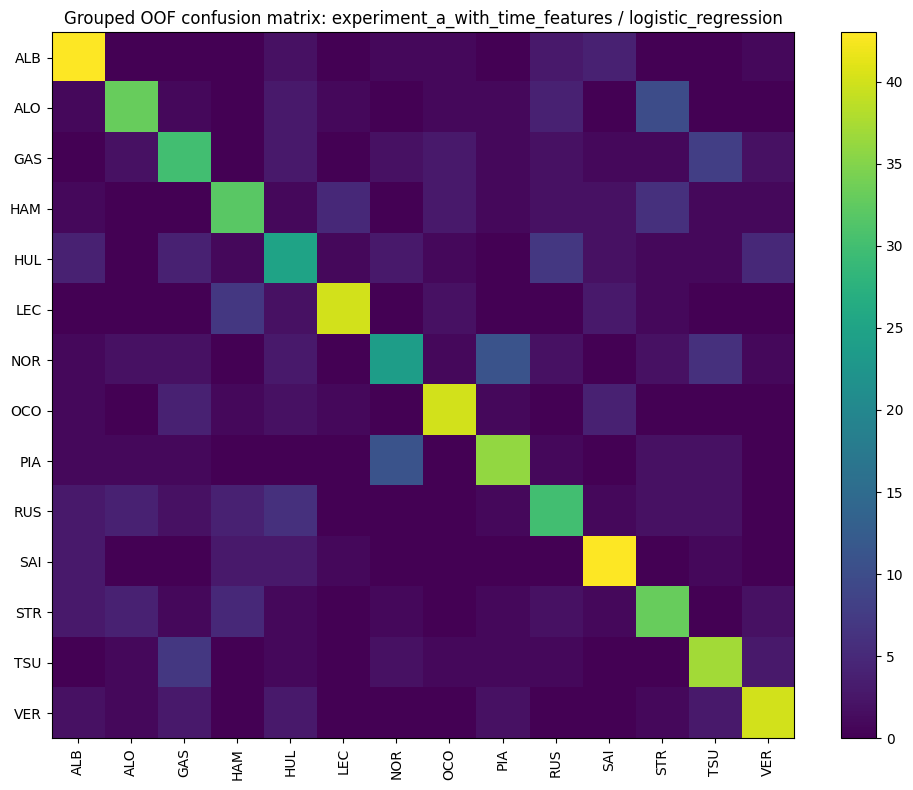

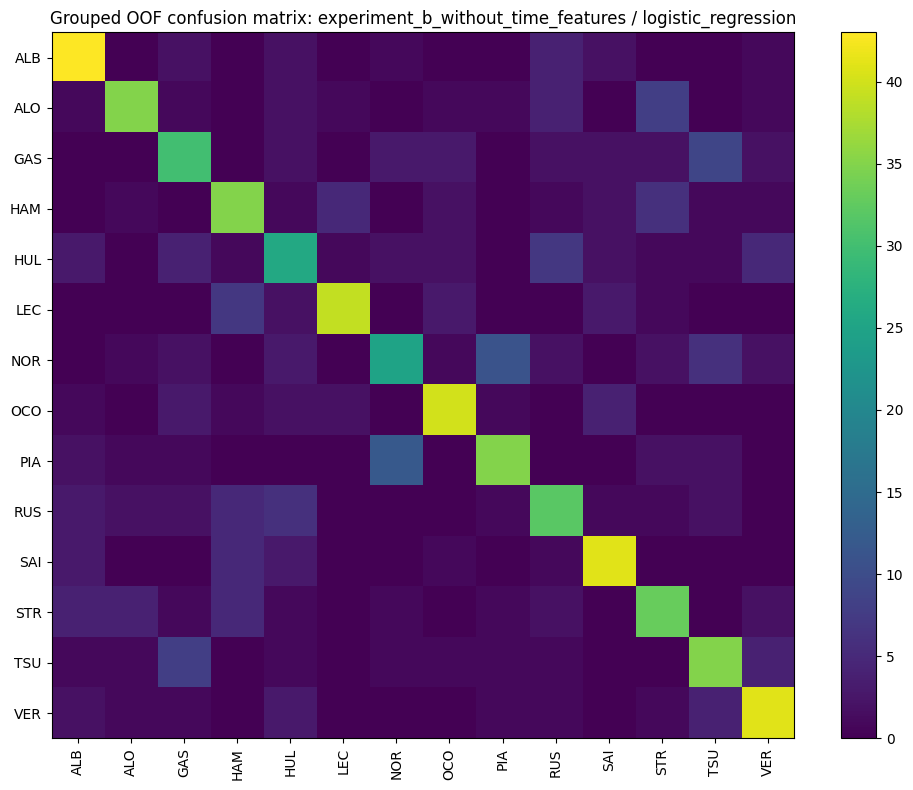

,experiment,model,importance_type,feature,importance
0,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__gear_mean,1.220672
1,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__gear_std,1.173742
2,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_zero_frac,1.128563
3,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_full_frac,1.031280
4,experiment_a_with_time_features,logistic_regression,mean_abs_coef,num__throttle_mid_frac,0.974037
...,...,...,...,...,...
364,experiment_b_without_time_features,xgboost,feature_importance,num__brake_std,0.021308
365,experiment_b_without_time_features,xgboost,feature_importance,cat__Compound_SOFT,0.021261
366,experiment_b_without_time_features,xgboost,feature_importance,num__rpm_diff_abs_mean,0.018815
367,experiment_b_without_time_features,xgboost,feature_importance,num__throttle_mid_frac,0.018501


In [5]:
display(grouped_model_summary_df.sort_values(["experiment", "oof_macro_f1"], ascending=[True, False]))
display(grouped_overfit_summary_df)
display(grouped_model_config_df)

for _, row in grouped_best_models_df.iterrows():
    experiment_name = row["experiment"]
    model_name = row["model"]
    subset = grouped_oof_predictions_df[
        (grouped_oof_predictions_df["experiment"] == experiment_name)
        & (grouped_oof_predictions_df["model"] == model_name)
    ].copy()
    labels = sorted(subset["true_driver"].unique())
    confusion = confusion_matrix(subset["true_driver"], subset["pred_driver"], labels=labels)
    plt.figure(figsize=(10, 8))
    plt.imshow(confusion, aspect="auto")
    plt.title(f"Grouped OOF confusion matrix: {experiment_name} / {model_name}")
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

top_importance_df = (
    grouped_feature_importance_df.sort_values(["experiment", "model", "importance"], ascending=[True, True, False])
    .groupby(["experiment", "model"], as_index=False)
    .head(15)
)
display(top_importance_df)

## Interpretation Guide

- If grouped test performance remains reasonably close to the random-fold baseline, the style signal is more credible.
- If train metrics are much higher than grouped test metrics, that points to overfitting.
- These are still baseline configurations, not final tuned models. A later tuning step should be done under grouped validation, not random CV.

## Source: `07_driver_subset_same_track_experiments.ipynb`


# 07 Driver Subset And Same-Track Experiments

This notebook turns the reduced-driver idea into a reproducible experiment.

It does three things:

- ranks drivers by how separable they already are under the best grouped baseline,
- ranks confusion pairs by how often they are mistaken for each other,
- evaluates reduced subsets with the best baseline model both across all sessions and within same-track subsets.

Important scope decision:

- The reduced-subset experiments use the current best-performing and least-overfitting baseline: logistic regression with the no-time feature set.
- Tree-based models are intentionally not reused here because grouped validation showed much larger train-test gaps for them.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import LeaveOneGroupOut, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5
BEST_EXPERIMENT = "experiment_b_without_time_features"
BEST_MODEL = "logistic_regression"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_logistic_pipeline(df: pd.DataFrame, feature_cols) -> Pipeline:
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", make_one_hot_encoder())]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", LogisticRegression(C=1.0, max_iter=5000, penalty="l2", solver="lbfgs", random_state=RANDOM_STATE)),
        ]
    )

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def evaluate_grouped_subset(df: pd.DataFrame, feature_cols, subset_name: str):
    X = df[feature_cols].copy()
    y = df["Driver"].copy()
    groups = df["session_key"].copy()
    estimator = build_logistic_pipeline(df, feature_cols)
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    fold_rows = []
    oof_pred = pd.Series(index=y.index, dtype="object")

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        fitted = build_logistic_pipeline(df, feature_cols)
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fitted.fit(X_train, y_train)
        y_pred_train = fitted.predict(X_train)
        y_pred_test = fitted.predict(X_test)
        oof_pred.iloc[test_idx] = y_pred_test

        row = {
            "subset_name": subset_name,
            "n_drivers": y.nunique(),
            "n_samples": len(df),
            "fold": fold_idx,
            "train_groups": groups.iloc[train_idx].nunique(),
            "test_groups": groups.iloc[test_idx].nunique(),
        }
        row.update(score_split(y_train, y_pred_train, prefix="train"))
        row.update(score_split(y_test, y_pred_test, prefix="test"))
        row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
        row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = pd.DataFrame(
        [
            {
                "subset_name": subset_name,
                "n_drivers": y.nunique(),
                "n_samples": len(df),
                "mean_train_accuracy": fold_df["train_accuracy"].mean(),
                "mean_test_accuracy": fold_df["test_accuracy"].mean(),
                "mean_accuracy_gap": fold_df["accuracy_gap"].mean(),
                "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
                "mean_test_macro_f1": fold_df["test_macro_f1"].mean(),
                "mean_macro_f1_gap": fold_df["macro_f1_gap"].mean(),
                "oof_accuracy": accuracy_score(y, oof_pred),
                "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
                "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
            }
        ]
    )

    oof_df = pd.DataFrame(
        {
            "lap_key": df["lap_key"],
            "subset_name": subset_name,
            "session_key": df["session_key"],
            "event_name": df["event_name"],
            "true_driver": y,
            "pred_driver": oof_pred,
        }
    )

    return fold_df, summary, oof_df

def evaluate_same_track_subset(df: pd.DataFrame, feature_cols, subset_name: str, min_sessions: int = 3):
    results = []
    logo = LeaveOneGroupOut()

    for event_name, event_df in df.groupby("event_name"):
        session_count = event_df["session_key"].nunique()
        if session_count < min_sessions:
            continue

        driver_count = event_df["Driver"].nunique()
        expected_samples = session_count * df["Driver"].nunique()
        full_coverage = len(event_df) == expected_samples and driver_count == df["Driver"].nunique()
        if not full_coverage:
            continue

        X = event_df[feature_cols].copy()
        y = event_df["Driver"].copy()
        groups = event_df["session_key"].copy()
        fold_rows = []

        for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, groups), start=1):
            y_train = y.iloc[train_idx]
            y_test = y.iloc[test_idx]
            if y_train.nunique() != y.nunique() or y_test.nunique() != y.nunique():
                continue

            fitted = build_logistic_pipeline(event_df, feature_cols)
            fitted.fit(X.iloc[train_idx], y_train)
            y_pred_train = fitted.predict(X.iloc[train_idx])
            y_pred_test = fitted.predict(X.iloc[test_idx])

            row = {
                "subset_name": subset_name,
                "event_name": event_name,
                "fold": fold_idx,
                "n_drivers": y.nunique(),
                "n_samples": len(event_df),
                "n_sessions": session_count,
                "test_session_key": groups.iloc[test_idx].iloc[0],
            }
            row.update(score_split(y_train, y_pred_train, prefix="train"))
            row.update(score_split(y_test, y_pred_test, prefix="test"))
            row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
            row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
            fold_rows.append(row)

        if fold_rows:
            fold_df = pd.DataFrame(fold_rows)
            results.append(
                {
                    "subset_name": subset_name,
                    "event_name": event_name,
                    "n_drivers": y.nunique(),
                    "n_samples": len(event_df),
                    "n_sessions": session_count,
                    "mean_train_accuracy": fold_df["train_accuracy"].mean(),
                    "mean_test_accuracy": fold_df["test_accuracy"].mean(),
                    "mean_accuracy_gap": fold_df["accuracy_gap"].mean(),
                    "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
                    "mean_test_macro_f1": fold_df["test_macro_f1"].mean(),
                    "mean_macro_f1_gap": fold_df["macro_f1_gap"].mean(),
                }
            )

    return pd.DataFrame(results)

In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
session_meta_df = pd.read_csv(EXPORT_DIR / "qualifying_session_audit.csv")[["season", "round", "event_name", "country", "location"]].drop_duplicates()
best_oof_df = pd.read_csv(EXPORT_DIR / "grouped_oof_predictions.csv")
best_oof_df = best_oof_df[(best_oof_df["experiment"] == BEST_EXPERIMENT) & (best_oof_df["model"] == BEST_MODEL)].copy()

features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)
features_df = features_df.merge(session_meta_df, on=["season", "round"], how="left")

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "event_name",
    "country",
    "location",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]
FEATURE_COLS = [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS]

print(f"Dataset shape: {features_df.shape}")
print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Best baseline for subset ranking: {BEST_EXPERIMENT} / {BEST_MODEL}")

Dataset shape: (766, 89)
Feature count: 64
Best baseline for subset ranking: experiment_b_without_time_features / logistic_regression


In [4]:
driver_recall_df = (
    best_oof_df.assign(correct=best_oof_df["true_driver"] == best_oof_df["pred_driver"])
    .groupby("true_driver")
    .agg(n_samples=("true_driver", "size"), n_correct=("correct", "sum"))
    .reset_index()
    .rename(columns={"true_driver": "driver"})
)
driver_recall_df["recall"] = driver_recall_df["n_correct"] / driver_recall_df["n_samples"]
driver_recall_df = driver_recall_df.sort_values(["recall", "driver"], ascending=[False, True]).reset_index(drop=True)

misclassified_df = best_oof_df[best_oof_df["true_driver"] != best_oof_df["pred_driver"]].copy()
misclassified_df["driver_a"] = misclassified_df[["true_driver", "pred_driver"]].min(axis=1)
misclassified_df["driver_b"] = misclassified_df[["true_driver", "pred_driver"]].max(axis=1)

pair_confusion_df = (
    misclassified_df.groupby(["driver_a", "driver_b"])
    .size()
    .reset_index(name="total_mutual_confusions")
    .sort_values(["total_mutual_confusions", "driver_a", "driver_b"], ascending=[False, True, True])
    .reset_index(drop=True)
)
pair_confusion_df["pair_name"] = pair_confusion_df["driver_a"] + "_vs_" + pair_confusion_df["driver_b"]

export_csv(driver_recall_df, "subset_driver_recall_ranking")
export_csv(pair_confusion_df, "subset_confusion_pair_ranking")

display(driver_recall_df)
display(pair_confusion_df.head(10))

,driver,n_samples,n_correct,recall
0,ALB,55,43,0.781818
1,SAI,54,41,0.759259
2,VER,55,41,0.745455
3,OCO,54,40,0.740741
4,LEC,55,39,0.709091
5,TSU,54,35,0.648148
6,ALO,55,35,0.636364
7,HAM,55,35,0.636364
8,PIA,55,35,0.636364
9,STR,54,33,0.611111


,driver_a,driver_b,total_mutual_confusions,pair_name
0,NOR,PIA,23,NOR_vs_PIA
1,GAS,TSU,17,GAS_vs_TSU
2,HUL,RUS,13,HUL_vs_RUS
3,ALO,STR,12,ALO_vs_STR
4,HAM,LEC,12,HAM_vs_LEC
5,HAM,STR,11,HAM_vs_STR
6,HUL,VER,8,HUL_vs_VER
7,TSU,VER,8,TSU_vs_VER
8,ALB,RUS,7,ALB_vs_RUS
9,HAM,SAI,7,HAM_vs_SAI


In [5]:
top5_distinctive = driver_recall_df.head(5)["driver"].tolist()
top6_distinctive = driver_recall_df.head(6)["driver"].tolist()
top8_distinctive = driver_recall_df.head(8)["driver"].tolist()

top3_pairs = pair_confusion_df.head(3)
confusion_union6 = sorted(set(top3_pairs["driver_a"]).union(set(top3_pairs["driver_b"])))

candidate_subsets = [
    {"subset_name": "distinctive_top5", "drivers": top5_distinctive, "subset_type": "distinctive"},
    {"subset_name": "distinctive_top6", "drivers": top6_distinctive, "subset_type": "distinctive"},
    {"subset_name": "distinctive_top8", "drivers": top8_distinctive, "subset_type": "distinctive"},
    {"subset_name": "confusion_union_top3_pairs", "drivers": confusion_union6, "subset_type": "confusion_union"},
]

for _, row in top3_pairs.iterrows():
    candidate_subsets.append(
        {
            "subset_name": f"confusion_pair_{row['driver_a']}_{row['driver_b']}",
            "drivers": [row["driver_a"], row["driver_b"]],
            "subset_type": "confusion_pair",
        }
    )

subset_definition_rows = []
for subset in candidate_subsets:
    for driver in subset["drivers"]:
        subset_definition_rows.append(
            {
                "subset_name": subset["subset_name"],
                "subset_type": subset["subset_type"],
                "driver": driver,
                "n_drivers": len(subset["drivers"]),
            }
        )

subset_definitions_df = pd.DataFrame(subset_definition_rows)
export_csv(subset_definitions_df, "subset_candidate_definitions")
display(subset_definitions_df)

,subset_name,subset_type,driver,n_drivers
0,distinctive_top5,distinctive,ALB,5
1,distinctive_top5,distinctive,SAI,5
2,distinctive_top5,distinctive,VER,5
3,distinctive_top5,distinctive,OCO,5
4,distinctive_top5,distinctive,LEC,5
5,distinctive_top6,distinctive,ALB,6
6,distinctive_top6,distinctive,SAI,6
7,distinctive_top6,distinctive,VER,6
8,distinctive_top6,distinctive,OCO,6
9,distinctive_top6,distinctive,LEC,6


In [6]:
grouped_fold_frames = []
grouped_summary_frames = []
grouped_oof_frames = []
same_track_sufficiency_rows = []
same_track_result_frames = []

for subset in candidate_subsets:
    subset_name = subset["subset_name"]
    drivers = subset["drivers"]
    subset_df = features_df[features_df["Driver"].isin(drivers)].copy()

    fold_df, summary_df, oof_df = evaluate_grouped_subset(subset_df, FEATURE_COLS, subset_name)
    grouped_fold_frames.append(fold_df)
    grouped_summary_frames.append(summary_df)
    grouped_oof_frames.append(oof_df)

    sufficiency_df = (
        subset_df.groupby("event_name")
        .agg(
            n_samples=("lap_key", "size"),
            n_sessions=("session_key", "nunique"),
            n_drivers_present=("Driver", "nunique"),
            n_seasons=("season", "nunique"),
        )
        .reset_index()
    )
    sufficiency_df["subset_name"] = subset_name
    sufficiency_df["expected_samples_if_full"] = sufficiency_df["n_sessions"] * len(drivers)
    sufficiency_df["full_coverage"] = (
        (sufficiency_df["n_drivers_present"] == len(drivers))
        & (sufficiency_df["n_samples"] == sufficiency_df["expected_samples_if_full"])
    )
    same_track_sufficiency_rows.append(sufficiency_df)

    same_track_result_df = evaluate_same_track_subset(subset_df, FEATURE_COLS, subset_name, min_sessions=3)
    if not same_track_result_df.empty:
        same_track_result_frames.append(same_track_result_df)

subset_grouped_fold_metrics_df = pd.concat(grouped_fold_frames, ignore_index=True)
subset_grouped_summary_df = pd.concat(grouped_summary_frames, ignore_index=True).sort_values(["oof_macro_f1", "oof_accuracy"], ascending=[False, False])
subset_grouped_oof_df = pd.concat(grouped_oof_frames, ignore_index=True)
same_track_sufficiency_df = pd.concat(same_track_sufficiency_rows, ignore_index=True)

if same_track_result_frames:
    same_track_event_results_df = pd.concat(same_track_result_frames, ignore_index=True)
else:
    same_track_event_results_df = pd.DataFrame()

if not same_track_event_results_df.empty:
    same_track_summary_df = (
        same_track_event_results_df.groupby("subset_name")
        .agg(
            n_events=("event_name", "nunique"),
            mean_event_test_accuracy=("mean_test_accuracy", "mean"),
            median_event_test_accuracy=("mean_test_accuracy", "median"),
            mean_event_test_macro_f1=("mean_test_macro_f1", "mean"),
            median_event_test_macro_f1=("mean_test_macro_f1", "median"),
            mean_event_macro_f1_gap=("mean_macro_f1_gap", "mean"),
        )
        .reset_index()
        .sort_values(["mean_event_test_macro_f1", "mean_event_test_accuracy"], ascending=[False, False])
    )
else:
    same_track_summary_df = pd.DataFrame()

export_csv(subset_grouped_fold_metrics_df, "subset_grouped_fold_metrics")
export_csv(subset_grouped_summary_df, "subset_grouped_summary")
export_csv(subset_grouped_oof_df, "subset_grouped_oof_predictions")
export_csv(same_track_sufficiency_df, "same_track_subset_sufficiency")
if not same_track_event_results_df.empty:
    export_csv(same_track_event_results_df, "same_track_event_results")
if not same_track_summary_df.empty:
    export_csv(same_track_summary_df, "same_track_subset_summary")

print("Exported:")
print("- exports/subset_driver_recall_ranking.csv")
print("- exports/subset_confusion_pair_ranking.csv")
print("- exports/subset_candidate_definitions.csv")
print("- exports/subset_grouped_fold_metrics.csv")
print("- exports/subset_grouped_summary.csv")
print("- exports/subset_grouped_oof_predictions.csv")
print("- exports/same_track_subset_sufficiency.csv")
if not same_track_event_results_df.empty:
    print("- exports/same_track_event_results.csv")
if not same_track_summary_df.empty:
    print("- exports/same_track_subset_summary.csv")

Exported:
- exports/subset_driver_recall_ranking.csv
- exports/subset_confusion_pair_ranking.csv
- exports/subset_candidate_definitions.csv
- exports/subset_grouped_fold_metrics.csv
- exports/subset_grouped_summary.csv
- exports/subset_grouped_oof_predictions.csv
- exports/same_track_subset_sufficiency.csv
- exports/same_track_event_results.csv
- exports/same_track_subset_summary.csv


,subset_name,n_drivers,n_samples,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,distinctive_top5,5,273,0.990842,0.857172,0.133671,0.990811,0.857580,0.133230,0.857143,0.856970,0.858051
1,distinctive_top6,6,327,0.980893,0.831888,0.149005,0.980958,0.831469,0.149490,0.831804,0.831706,0.833021
5,confusion_pair_GAS_TSU,2,109,0.912879,0.806926,0.105952,0.912859,0.804299,0.108560,0.807339,0.807576,0.807275
6,confusion_pair_HUL_RUS,2,110,0.915909,0.772727,0.143182,0.915857,0.770763,0.145094,0.772727,0.772727,0.771803
2,distinctive_top8,8,437,0.963956,0.766745,0.197211,0.964082,0.764763,0.199319,0.766590,0.766709,0.766995
4,confusion_pair_NOR_PIA,2,110,0.845455,0.709091,0.136364,0.845399,0.706420,0.138979,0.709091,0.709091,0.708995
3,confusion_union_top3_pairs,6,329,0.857158,0.586620,0.270538,0.857187,0.579135,0.278053,0.586626,0.586925,0.584740


,event_name,n_samples,n_sessions,n_drivers_present,n_seasons,subset_name,expected_samples_if_full,full_coverage
120,Abu Dhabi Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
122,Austrian Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
124,Bahrain Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
132,Italian Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
133,Japanese Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
135,Mexico City Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
136,Miami Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
137,Monaco Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
138,Qatar Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True
139,Saudi Arabian Grand Prix,6,3,2,3,confusion_pair_GAS_TSU,6,True


,subset_name,n_events,mean_event_test_accuracy,median_event_test_accuracy,mean_event_test_macro_f1,median_event_test_macro_f1,mean_event_macro_f1_gap
1,confusion_pair_HUL_RUS,12,0.736111,0.666667,0.666667,0.555556,0.333333
0,confusion_pair_GAS_TSU,12,0.638889,0.666667,0.546296,0.555556,0.453704
4,distinctive_top5,10,0.606667,0.633333,0.522000,0.552222,0.478000
2,confusion_pair_NOR_PIA,12,0.625000,0.583333,0.509259,0.500000,0.490741
5,distinctive_top6,10,0.572222,0.583333,0.478704,0.472222,0.521296
6,distinctive_top8,10,0.500000,0.520833,0.409861,0.423611,0.590139
3,confusion_union_top3_pairs,12,0.500000,0.527778,0.405247,0.441667,0.594753


,subset_name,event_name,n_drivers,n_samples,n_sessions,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap
61,confusion_pair_GAS_TSU,Monaco Grand Prix,2,6,3,1.0,0.833333,0.166667,1.0,0.777778,0.222222
56,confusion_pair_GAS_TSU,Bahrain Grand Prix,2,6,3,1.0,0.833333,0.166667,1.0,0.777778,0.222222
62,confusion_pair_GAS_TSU,Qatar Grand Prix,2,6,3,1.0,0.833333,0.166667,1.0,0.777778,0.222222
64,confusion_pair_GAS_TSU,Singapore Grand Prix,2,6,3,1.0,0.833333,0.166667,1.0,0.777778,0.222222
65,confusion_pair_GAS_TSU,United States Grand Prix,2,6,3,1.0,0.833333,0.166667,1.0,0.777778,0.222222
55,confusion_pair_GAS_TSU,Austrian Grand Prix,2,6,3,1.0,0.666667,0.333333,1.0,0.555556,0.444444
57,confusion_pair_GAS_TSU,Italian Grand Prix,2,6,3,1.0,0.666667,0.333333,1.0,0.555556,0.444444
60,confusion_pair_GAS_TSU,Miami Grand Prix,2,6,3,1.0,0.666667,0.333333,1.0,0.555556,0.444444
54,confusion_pair_GAS_TSU,Abu Dhabi Grand Prix,2,6,3,1.0,0.500000,0.500000,1.0,0.333333,0.666667
63,confusion_pair_GAS_TSU,Saudi Arabian Grand Prix,2,6,3,1.0,0.500000,0.500000,1.0,0.333333,0.666667


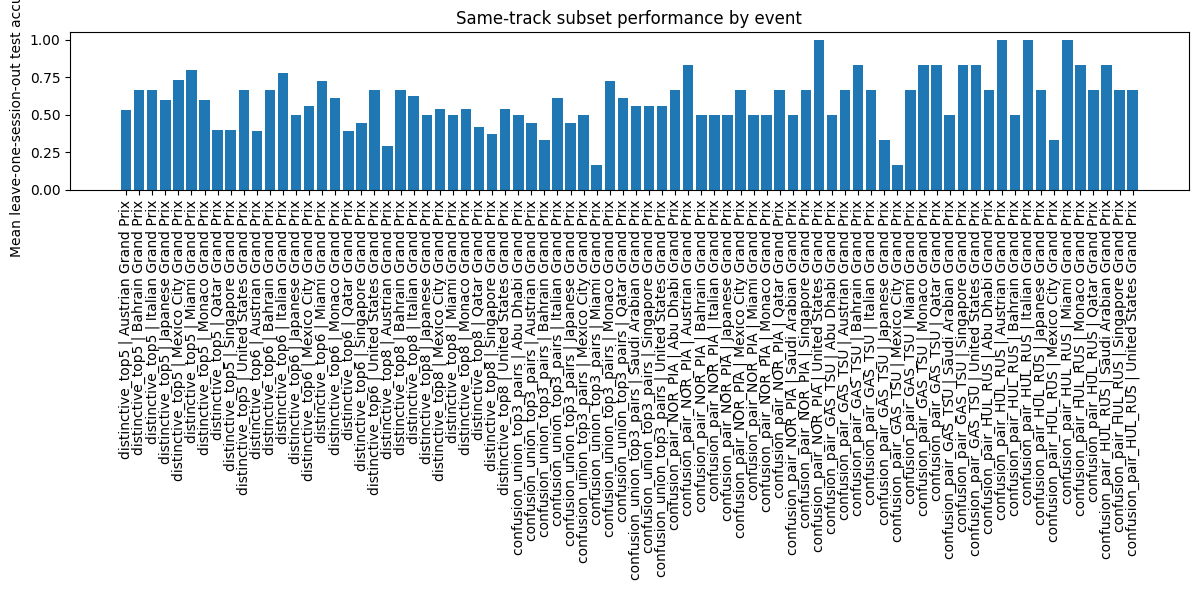

In [7]:
display(subset_grouped_summary_df)
display(same_track_sufficiency_df.sort_values(["subset_name", "n_sessions", "n_samples"], ascending=[True, False, False]).head(30))

if not same_track_summary_df.empty:
    display(same_track_summary_df)
    display(same_track_event_results_df.sort_values(["subset_name", "mean_test_macro_f1", "mean_test_accuracy"], ascending=[True, False, False]).head(30))

    plt.figure(figsize=(12, 6))
    plot_df = same_track_event_results_df.copy()
    x = np.arange(len(plot_df))
    plt.bar(x, plot_df["mean_test_accuracy"])
    plt.xticks(x, plot_df["subset_name"] + " | " + plot_df["event_name"], rotation=90)
    plt.ylabel("Mean leave-one-session-out test accuracy")
    plt.title("Same-track subset performance by event")
    plt.tight_layout()
    plt.show()

## Interpretation Notes

- Reduced subsets that stay strong under grouped cross-track validation are good candidates for a focused thesis experiment.
- Same-track results should be interpreted more cautiously because each event only contributes one best lap per driver per season.
- If same-track results improve while sample size shrinks, that supports the idea that fixed track context helps reveal style, but it does not replace the larger cross-track experiment.

## Source: `08_tuned_logistic_regression_distinctive_subsets.ipynb`


# 08 Tuned Logistic Regression For Distinctive Driver Subsets

This notebook tunes the strongest baseline model from the previous experiments:

- model: logistic regression
- feature set: no-time engineered features
- validation: grouped by qualifying session
- target subsets: `distinctive_top5` and `distinctive_top6`

Goal:

- improve the strongest thesis-ready setup without introducing the overfitting-heavy tree models,
- compare tuned results against the already exported baseline subset results,
- keep every output exportable as CSV for external verification.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_logistic_pipeline(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight):
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", make_one_hot_encoder())]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    solver = "lbfgs" if penalty == "l2" else "saga"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        max_iter=7000,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def evaluate_param_config(df: pd.DataFrame, feature_cols, subset_name: str, penalty: str, C: float, class_weight):
    X = df[feature_cols].copy()
    y = df["Driver"].copy()
    groups = df["session_key"].copy()
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    fold_rows = []
    oof_pred = pd.Series(index=y.index, dtype="object")

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        fitted = build_logistic_pipeline(df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fitted.fit(X_train, y_train)
        y_pred_train = fitted.predict(X_train)
        y_pred_test = fitted.predict(X_test)
        oof_pred.iloc[test_idx] = y_pred_test

        row = {
            "subset_name": subset_name,
            "penalty": penalty,
            "C": C,
            "class_weight": "balanced" if class_weight == "balanced" else "none",
            "fold": fold_idx,
        }
        row.update(score_split(y_train, y_pred_train, prefix="train"))
        row.update(score_split(y_test, y_pred_test, prefix="test"))
        row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
        row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "subset_name": subset_name,
        "penalty": penalty,
        "C": C,
        "class_weight": "balanced" if class_weight == "balanced" else "none",
        "n_drivers": y.nunique(),
        "n_samples": len(df),
        "mean_train_accuracy": fold_df["train_accuracy"].mean(),
        "mean_test_accuracy": fold_df["test_accuracy"].mean(),
        "mean_accuracy_gap": fold_df["accuracy_gap"].mean(),
        "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
        "mean_test_macro_f1": fold_df["test_macro_f1"].mean(),
        "mean_macro_f1_gap": fold_df["macro_f1_gap"].mean(),
        "oof_accuracy": accuracy_score(y, oof_pred),
        "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
        "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
    }
    return fold_df, summary

def fit_full_and_extract_coefficients(df: pd.DataFrame, feature_cols, subset_name: str, penalty: str, C: float, class_weight):
    X = df[feature_cols].copy()
    y = df["Driver"].copy()
    fitted = build_logistic_pipeline(df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
    fitted.fit(X, y)

    preprocessor = fitted.named_steps["preprocess"]
    model = fitted.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    coef_abs_mean = np.abs(model.coef_).mean(axis=0)

    coef_df = pd.DataFrame(
        {
            "subset_name": subset_name,
            "penalty": penalty,
            "C": C,
            "class_weight": "balanced" if class_weight == "balanced" else "none",
            "feature": feature_names,
            "importance": coef_abs_mean,
        }
    ).sort_values("importance", ascending=False)
    return coef_df

In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
subset_defs_df = pd.read_csv(EXPORT_DIR / "subset_candidate_definitions.csv")
baseline_subset_summary_df = pd.read_csv(EXPORT_DIR / "subset_grouped_summary.csv")

features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]
FEATURE_COLS = [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS]

target_subsets = ["distinctive_top5", "distinctive_top6"]
param_grid = []
for penalty in ["l2", "l1"]:
    for C in [0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 4.0, 8.0]:
        for class_weight in [None, "balanced"]:
            param_grid.append({"penalty": penalty, "C": C, "class_weight": class_weight})

print(f"Feature count: {len(FEATURE_COLS)}")
print(f"Parameter combinations: {len(param_grid)}")
print(f"Target subsets: {target_subsets}")

Feature count: 64
Parameter combinations: 32
Target subsets: ['distinctive_top5', 'distinctive_top6']


In [4]:
all_fold_rows = []
all_summary_rows = []

for subset_name in target_subsets:
    drivers = subset_defs_df[subset_defs_df["subset_name"] == subset_name]["driver"].tolist()
    subset_df = features_df[features_df["Driver"].isin(drivers)].copy()
    print(f"Running tuning for {subset_name} with drivers: {drivers}")

    for params in param_grid:
        fold_df, summary_row = evaluate_param_config(
            subset_df,
            feature_cols=FEATURE_COLS,
            subset_name=subset_name,
            penalty=params["penalty"],
            C=params["C"],
            class_weight=params["class_weight"],
        )
        all_fold_rows.append(fold_df)
        all_summary_rows.append(summary_row)

tuning_fold_metrics_df = pd.concat(all_fold_rows, ignore_index=True)
tuning_summary_df = pd.DataFrame(all_summary_rows)
tuning_summary_df = tuning_summary_df.sort_values(["subset_name", "oof_macro_f1", "oof_accuracy", "mean_macro_f1_gap"], ascending=[True, False, False, True]).reset_index(drop=True)

best_params_df = tuning_summary_df.groupby("subset_name", as_index=False).head(1).reset_index(drop=True)

baseline_compare_df = baseline_subset_summary_df[baseline_subset_summary_df["subset_name"].isin(target_subsets)].copy()
baseline_compare_df = baseline_compare_df[["subset_name", "oof_accuracy", "oof_macro_f1", "mean_accuracy_gap", "mean_macro_f1_gap"]]
baseline_compare_df = baseline_compare_df.rename(columns={
    "oof_accuracy": "baseline_oof_accuracy",
    "oof_macro_f1": "baseline_oof_macro_f1",
    "mean_accuracy_gap": "baseline_mean_accuracy_gap",
    "mean_macro_f1_gap": "baseline_mean_macro_f1_gap",
})

best_vs_baseline_df = best_params_df.merge(baseline_compare_df, on="subset_name", how="left")
best_vs_baseline_df["accuracy_gain_vs_baseline"] = best_vs_baseline_df["oof_accuracy"] - best_vs_baseline_df["baseline_oof_accuracy"]
best_vs_baseline_df["macro_f1_gain_vs_baseline"] = best_vs_baseline_df["oof_macro_f1"] - best_vs_baseline_df["baseline_oof_macro_f1"]
best_vs_baseline_df["accuracy_gap_change_vs_baseline"] = best_vs_baseline_df["mean_accuracy_gap"] - best_vs_baseline_df["baseline_mean_accuracy_gap"]
best_vs_baseline_df["macro_f1_gap_change_vs_baseline"] = best_vs_baseline_df["mean_macro_f1_gap"] - best_vs_baseline_df["baseline_mean_macro_f1_gap"]

export_csv(tuning_fold_metrics_df, "logreg_tuning_fold_metrics")
export_csv(tuning_summary_df, "logreg_tuning_summary")
export_csv(best_params_df, "logreg_tuning_best_params")
export_csv(best_vs_baseline_df, "logreg_tuning_best_vs_baseline")

print("Exported:")
print("- exports/logreg_tuning_fold_metrics.csv")
print("- exports/logreg_tuning_summary.csv")
print("- exports/logreg_tuning_best_params.csv")
print("- exports/logreg_tuning_best_vs_baseline.csv")

Running tuning for distinctive_top5 with drivers: ['ALB', 'SAI', 'VER', 'OCO', 'LEC']


Running tuning for distinctive_top6 with drivers: ['ALB', 'SAI', 'VER', 'OCO', 'LEC', 'TSU']


Exported:
- exports/logreg_tuning_fold_metrics.csv
- exports/logreg_tuning_summary.csv
- exports/logreg_tuning_best_params.csv
- exports/logreg_tuning_best_vs_baseline.csv


In [5]:
coef_frames = []
for _, row in best_params_df.iterrows():
    subset_name = row["subset_name"]
    drivers = subset_defs_df[subset_defs_df["subset_name"] == subset_name]["driver"].tolist()
    subset_df = features_df[features_df["Driver"].isin(drivers)].copy()
    coef_df = fit_full_and_extract_coefficients(
        subset_df,
        feature_cols=FEATURE_COLS,
        subset_name=subset_name,
        penalty=row["penalty"],
        C=row["C"],
        class_weight=None if row["class_weight"] == "none" else "balanced",
    )
    coef_frames.append(coef_df)

best_coef_df = pd.concat(coef_frames, ignore_index=True)
best_coef_top_df = best_coef_df.groupby("subset_name", as_index=False).head(20)
export_csv(best_coef_df, "logreg_tuning_best_feature_importance")
print("- exports/logreg_tuning_best_feature_importance.csv")

- exports/logreg_tuning_best_feature_importance.csv


,subset_name,penalty,C,class_weight,n_drivers,n_samples,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,distinctive_top5,l1,2.0,none,5,273,0.989925,0.857172,0.132753,0.989860,0.858659,0.131201,0.857143,0.856970,0.858420
1,distinctive_top6,l2,1.0,balanced,6,327,0.980126,0.831888,0.148238,0.980192,0.831450,0.148742,0.831804,0.831706,0.833021


,subset_name,penalty,C,class_weight,n_drivers,n_samples,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,baseline_oof_accuracy,baseline_oof_macro_f1,baseline_mean_accuracy_gap,baseline_mean_macro_f1_gap,accuracy_gain_vs_baseline,macro_f1_gain_vs_baseline,accuracy_gap_change_vs_baseline,macro_f1_gap_change_vs_baseline
0,distinctive_top5,l1,2.0,none,5,273,0.989925,0.857172,0.132753,0.989860,0.858659,0.131201,0.857143,0.856970,0.858420,0.857143,0.858051,0.133671,0.13323,0.0,0.000368,-0.000917,-0.002029
1,distinctive_top6,l2,1.0,balanced,6,327,0.980126,0.831888,0.148238,0.980192,0.831450,0.148742,0.831804,0.831706,0.833021,0.831804,0.833021,0.149005,0.14949,0.0,0.000000,-0.000766,-0.000747


,subset_name,penalty,C,class_weight,n_drivers,n_samples,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,distinctive_top5,l1,2.0,none,5,273,0.989925,0.857172,0.132753,0.989860,0.858659,0.131201,0.857143,0.856970,0.858420
1,distinctive_top5,l1,2.0,balanced,5,273,0.989925,0.857172,0.132753,0.989860,0.858127,0.131733,0.857143,0.856970,0.858150
2,distinctive_top5,l2,1.0,none,5,273,0.990842,0.857172,0.133671,0.990811,0.857580,0.133230,0.857143,0.856970,0.858051
3,distinctive_top5,l2,1.0,balanced,5,273,0.990842,0.857172,0.133671,0.990811,0.857580,0.133230,0.857143,0.856970,0.858051
4,distinctive_top5,l2,2.0,none,5,273,0.998169,0.853468,0.144701,0.998171,0.853944,0.144227,0.853480,0.853333,0.854431
5,distinctive_top5,l2,2.0,balanced,5,273,0.998169,0.853468,0.144701,0.998171,0.853944,0.144227,0.853480,0.853333,0.854431
6,distinctive_top5,l1,1.0,none,5,273,0.972527,0.849899,0.122628,0.972422,0.852152,0.120269,0.849817,0.849697,0.851737
7,distinctive_top5,l1,1.0,balanced,5,273,0.972527,0.849899,0.122628,0.972422,0.852152,0.120269,0.849817,0.849697,0.851737
8,distinctive_top5,l2,4.0,none,5,273,1.000000,0.849899,0.150101,1.000000,0.849782,0.150218,0.849817,0.849697,0.850825
9,distinctive_top5,l2,4.0,balanced,5,273,1.000000,0.849899,0.150101,1.000000,0.849557,0.150443,0.849817,0.849697,0.850814


,subset_name,penalty,C,class_weight,feature,importance
0,distinctive_top5,l1,2.0,none,num__gear_mean,2.066866
1,distinctive_top5,l1,2.0,none,num__throttle_diff_abs_mean,1.114947
2,distinctive_top5,l1,2.0,none,num__throttle_diff_std,1.064017
3,distinctive_top5,l1,2.0,none,num__throttle_mid_frac,1.014053
4,distinctive_top5,l1,2.0,none,num__throttle_zero_frac,0.915453
5,distinctive_top5,l1,2.0,none,num__rpm_diff_abs_mean,0.882172
6,distinctive_top5,l1,2.0,none,num__speed_std,0.802322
7,distinctive_top5,l1,2.0,none,num__rpm_median,0.571078
8,distinctive_top5,l1,2.0,none,num__gear_change_count,0.551410
9,distinctive_top5,l1,2.0,none,num__throttle_std,0.513852


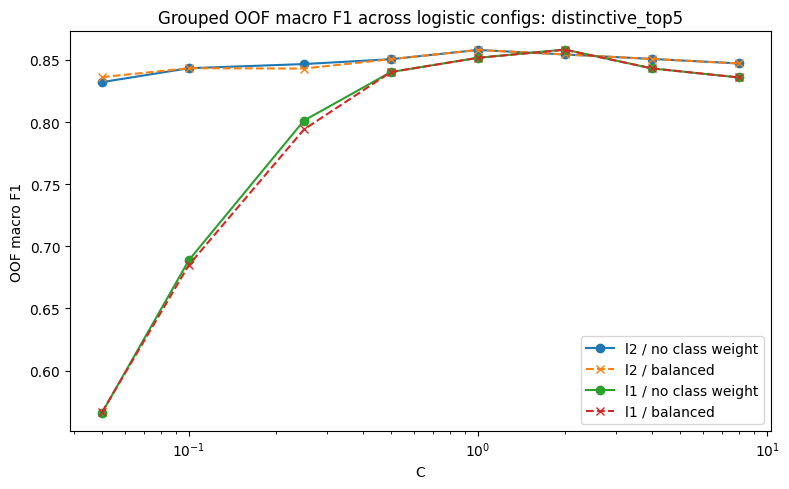

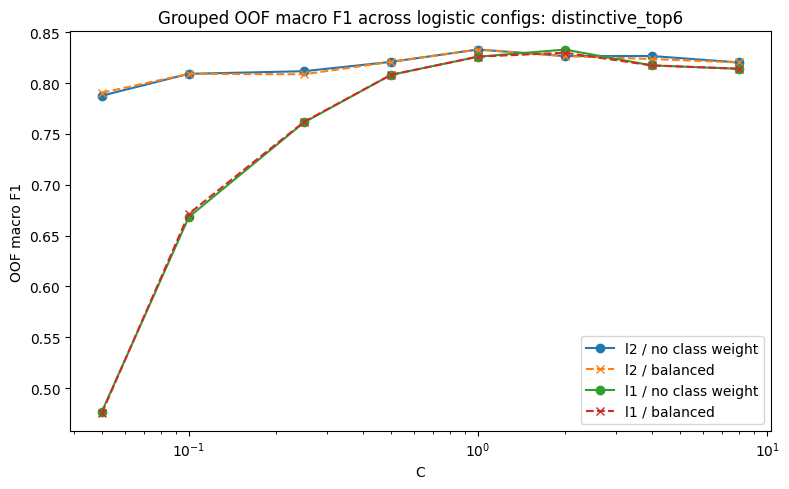

In [6]:
display(best_params_df)
display(best_vs_baseline_df)
display(tuning_summary_df.groupby("subset_name", as_index=False).head(10))
display(best_coef_top_df)

for subset_name, subset_plot_df in tuning_summary_df.groupby("subset_name"):
    plt.figure(figsize=(8, 5))
    for penalty in ["l2", "l1"]:
        line_df = subset_plot_df[(subset_plot_df["penalty"] == penalty) & (subset_plot_df["class_weight"] == "none")].sort_values("C")
        plt.plot(line_df["C"], line_df["oof_macro_f1"], marker="o", label=f"{penalty} / no class weight")
        line_df_bal = subset_plot_df[(subset_plot_df["penalty"] == penalty) & (subset_plot_df["class_weight"] == "balanced")].sort_values("C")
        plt.plot(line_df_bal["C"], line_df_bal["oof_macro_f1"], marker="x", linestyle="--", label=f"{penalty} / balanced")
    plt.xscale("log")
    plt.title(f"Grouped OOF macro F1 across logistic configs: {subset_name}")
    plt.xlabel("C")
    plt.ylabel("OOF macro F1")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Interpretation Notes

- These tuned results are useful for model selection inside the thesis pipeline.
- For final reporting, keep the distinction clear between baseline results and tuned results.
- If the tuned gain is small, that is still informative: it means the simpler baseline was already close to optimal for this feature representation.

## Source: `09_feature_family_ablation.ipynb`


# 09 Feature Family Ablation

This notebook asks which telemetry families actually carry the driver-style signal in the strongest reduced-driver experiments.

Design:

- subsets: `distinctive_top5` and `distinctive_top6`
- model: tuned logistic regression for each subset
- validation: grouped by qualifying session
- comparisons:
  - **family-only** models: how much signal each family carries on its own
  - **leave-one-family-out** models: how much the full model loses when one family is removed

This should make the telemetry interpretation chapter much stronger later.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_logistic_pipeline(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight):
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", make_one_hot_encoder())]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    solver = "lbfgs" if penalty == "l2" else "saga"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        max_iter=7000,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def evaluate_feature_config(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight, subset_name: str, config_name: str, config_type: str):
    X = df[feature_cols].copy()
    y = df["Driver"].copy()
    groups = df["session_key"].copy()
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    fold_rows = []
    oof_pred = pd.Series(index=y.index, dtype="object")

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        fitted = build_logistic_pipeline(df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fitted.fit(X_train, y_train)
        y_pred_train = fitted.predict(X_train)
        y_pred_test = fitted.predict(X_test)
        oof_pred.iloc[test_idx] = y_pred_test

        row = {
            "subset_name": subset_name,
            "config_name": config_name,
            "config_type": config_type,
            "n_features": len(feature_cols),
            "fold": fold_idx,
        }
        row.update(score_split(y_train, y_pred_train, prefix="train"))
        row.update(score_split(y_test, y_pred_test, prefix="test"))
        row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
        row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "subset_name": subset_name,
        "config_name": config_name,
        "config_type": config_type,
        "n_features": len(feature_cols),
        "mean_train_accuracy": fold_df["train_accuracy"].mean(),
        "mean_test_accuracy": fold_df["test_accuracy"].mean(),
        "mean_accuracy_gap": fold_df["accuracy_gap"].mean(),
        "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
        "mean_test_macro_f1": fold_df["test_macro_f1"].mean(),
        "mean_macro_f1_gap": fold_df["macro_f1_gap"].mean(),
        "oof_accuracy": accuracy_score(y, oof_pred),
        "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
        "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
    }
    return fold_df, summary


In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
subset_defs_df = pd.read_csv(EXPORT_DIR / "subset_candidate_definitions.csv")
tuned_params_df = pd.read_csv(EXPORT_DIR / "logreg_tuning_best_params.csv")

features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]
ALL_FEATURES = [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS]

feature_families = {
    "context": ["Compound", "TyreLife", "n_samples"],
    "speed": [
        "speed_mean", "speed_std", "speed_min", "speed_max", "speed_median", "speed_range", "speed_cv",
        "speed_p10", "speed_p25", "speed_p75", "speed_p90",
    ],
    "throttle": [
        "throttle_mean", "throttle_std", "throttle_max", "throttle_median",
        "throttle_zero_frac", "throttle_low_frac", "throttle_mid_frac", "throttle_high_frac", "throttle_full_frac",
        "throttle_p10", "throttle_p25", "throttle_p75", "throttle_p90",
    ],
    "brake": [
        "brake_mean", "brake_std", "brake_max", "brake_active_frac", "brake_on_count", "brake_p90",
    ],
    "powertrain": [
        "rpm_mean", "rpm_std", "rpm_min", "rpm_max", "rpm_median", "rpm_cv",
        "gear_mean", "gear_std", "gear_min", "gear_max", "gear_median", "gear_change_count",
    ],
    "phase": [
        "first_brake_frac_pos", "last_brake_frac_pos", "first_full_throttle_frac_pos", "last_full_throttle_frac_pos",
    ],
    "dynamics": [
        "speed_diff_mean", "speed_diff_std", "speed_diff_abs_mean", "speed_diff_abs_max",
        "throttle_diff_mean", "throttle_diff_std", "throttle_diff_abs_mean", "throttle_diff_abs_max",
        "brake_diff_std", "brake_diff_abs_mean", "brake_diff_abs_max",
        "rpm_diff_mean", "rpm_diff_std", "rpm_diff_abs_mean", "rpm_diff_abs_max",
    ],
}

feature_family_rows = []
for family_name, cols in feature_families.items():
    for col in cols:
        feature_family_rows.append({"family": family_name, "feature": col})
feature_family_df = pd.DataFrame(feature_family_rows)
export_csv(feature_family_df, "feature_family_mapping")

missing_features = sorted(set(feature_family_df['feature']) - set(ALL_FEATURES))
uncategorized_features = sorted(set(ALL_FEATURES) - set(feature_family_df['feature']))

print('Mapped families:', list(feature_families.keys()))
print('Missing mapped features:', missing_features)
print('Uncategorized features:', uncategorized_features)

Mapped families: ['context', 'speed', 'throttle', 'brake', 'powertrain', 'phase', 'dynamics']
Missing mapped features: []
Uncategorized features: []


In [4]:
target_subsets = ["distinctive_top5", "distinctive_top6"]

family_only_configs = []
for family_name, cols in feature_families.items():
    family_only_configs.append({
        "config_name": f"only_{family_name}",
        "config_type": "family_only",
        "feature_cols": cols,
        "family": family_name,
    })

family_only_configs.extend([
    {
        "config_name": "only_controls",
        "config_type": "family_only",
        "feature_cols": feature_families["throttle"] + feature_families["brake"] + feature_families["phase"],
        "family": "controls",
    },
    {
        "config_name": "only_vehicle_state",
        "config_type": "family_only",
        "feature_cols": feature_families["speed"] + feature_families["powertrain"] + feature_families["dynamics"],
        "family": "vehicle_state",
    },
])

leave_one_out_configs = []
for family_name, cols in feature_families.items():
    leave_one_out_configs.append({
        "config_name": f"no_{family_name}",
        "config_type": "leave_one_out",
        "feature_cols": [c for c in ALL_FEATURES if c not in cols],
        "family": family_name,
    })

config_definitions = [{
    "config_name": "full_model",
    "config_type": "full",
    "feature_cols": ALL_FEATURES,
    "family": "all",
}] + family_only_configs + leave_one_out_configs

config_rows = []
for config in config_definitions:
    config_rows.append({
        "config_name": config["config_name"],
        "config_type": config["config_type"],
        "family": config["family"],
        "n_features": len(config["feature_cols"]),
    })
config_df = pd.DataFrame(config_rows)
export_csv(config_df, "feature_family_ablation_configurations")
display(config_df)

,config_name,config_type,family,n_features
0,full_model,full,all,64
1,only_context,family_only,context,3
2,only_speed,family_only,speed,11
3,only_throttle,family_only,throttle,13
4,only_brake,family_only,brake,6
5,only_powertrain,family_only,powertrain,12
6,only_phase,family_only,phase,4
7,only_dynamics,family_only,dynamics,15
8,only_controls,family_only,controls,23
9,only_vehicle_state,family_only,vehicle_state,38


In [5]:
all_fold_frames = []
all_summary_rows = []

for subset_name in target_subsets:
    drivers = subset_defs_df[subset_defs_df["subset_name"] == subset_name]["driver"].tolist()
    subset_df = features_df[features_df["Driver"].isin(drivers)].copy()
    tuned_row = tuned_params_df[tuned_params_df["subset_name"] == subset_name].iloc[0]
    penalty = tuned_row["penalty"]
    C = float(tuned_row["C"])
    class_weight = None if tuned_row["class_weight"] == "none" else "balanced"
    print(f"Running ablation for {subset_name} with penalty={penalty}, C={C}, class_weight={tuned_row['class_weight']}")

    for config in config_definitions:
        fold_df, summary = evaluate_feature_config(
            subset_df,
            feature_cols=config["feature_cols"],
            penalty=penalty,
            C=C,
            class_weight=class_weight,
            subset_name=subset_name,
            config_name=config["config_name"],
            config_type=config["config_type"],
        )
        summary["family"] = config["family"]
        all_fold_frames.append(fold_df)
        all_summary_rows.append(summary)

ablation_fold_metrics_df = pd.concat(all_fold_frames, ignore_index=True)
ablation_summary_df = pd.DataFrame(all_summary_rows)

full_reference_df = ablation_summary_df[ablation_summary_df["config_name"] == "full_model"][['subset_name', 'oof_accuracy', 'oof_macro_f1', 'mean_accuracy_gap', 'mean_macro_f1_gap']].copy()
full_reference_df = full_reference_df.rename(columns={
    'oof_accuracy': 'full_oof_accuracy',
    'oof_macro_f1': 'full_oof_macro_f1',
    'mean_accuracy_gap': 'full_mean_accuracy_gap',
    'mean_macro_f1_gap': 'full_mean_macro_f1_gap',
})

ablation_summary_df = ablation_summary_df.merge(full_reference_df, on='subset_name', how='left')
ablation_summary_df['delta_oof_accuracy_vs_full'] = ablation_summary_df['oof_accuracy'] - ablation_summary_df['full_oof_accuracy']
ablation_summary_df['delta_oof_macro_f1_vs_full'] = ablation_summary_df['oof_macro_f1'] - ablation_summary_df['full_oof_macro_f1']
ablation_summary_df['delta_accuracy_gap_vs_full'] = ablation_summary_df['mean_accuracy_gap'] - ablation_summary_df['full_mean_accuracy_gap']
ablation_summary_df['delta_macro_f1_gap_vs_full'] = ablation_summary_df['mean_macro_f1_gap'] - ablation_summary_df['full_mean_macro_f1_gap']

family_only_rank_df = ablation_summary_df[ablation_summary_df['config_type'] == 'family_only'].sort_values(['subset_name', 'oof_macro_f1'], ascending=[True, False]).reset_index(drop=True)
leave_one_out_impact_df = ablation_summary_df[ablation_summary_df['config_type'] == 'leave_one_out'].sort_values(['subset_name', 'delta_oof_macro_f1_vs_full']).reset_index(drop=True)

export_csv(ablation_fold_metrics_df, 'feature_family_ablation_fold_metrics')
export_csv(ablation_summary_df, 'feature_family_ablation_summary')
export_csv(family_only_rank_df, 'feature_family_ablation_family_only_ranking')
export_csv(leave_one_out_impact_df, 'feature_family_ablation_leave_one_out_impact')

print('Exported:')
print('- exports/feature_family_mapping.csv')
print('- exports/feature_family_ablation_configurations.csv')
print('- exports/feature_family_ablation_fold_metrics.csv')
print('- exports/feature_family_ablation_summary.csv')
print('- exports/feature_family_ablation_family_only_ranking.csv')
print('- exports/feature_family_ablation_leave_one_out_impact.csv')

Running ablation for distinctive_top5 with penalty=l1, C=2.0, class_weight=none


Running ablation for distinctive_top6 with penalty=l2, C=1.0, class_weight=balanced


Exported:
- exports/feature_family_mapping.csv
- exports/feature_family_ablation_configurations.csv
- exports/feature_family_ablation_fold_metrics.csv
- exports/feature_family_ablation_summary.csv
- exports/feature_family_ablation_family_only_ranking.csv
- exports/feature_family_ablation_leave_one_out_impact.csv


,subset_name,config_name,config_type,n_features,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,family,full_oof_accuracy,full_oof_macro_f1,full_mean_accuracy_gap,full_mean_macro_f1_gap,delta_oof_accuracy_vs_full,delta_oof_macro_f1_vs_full,delta_accuracy_gap_vs_full,delta_macro_f1_gap_vs_full
9,distinctive_top5,only_vehicle_state,family_only,38,0.945964,0.805791,0.140172,0.945843,0.803371,0.142472,0.805861,0.805589,0.804675,vehicle_state,0.857143,0.858420,0.132753,0.131201,-0.051282,-0.053745,0.007419,0.011270
8,distinctive_top5,only_controls,family_only,23,0.777500,0.728956,0.048544,0.775582,0.727124,0.048459,0.728938,0.728485,0.728478,controls,0.857143,0.858420,0.132753,0.131201,-0.128205,-0.129941,-0.084210,-0.082743
7,distinctive_top5,only_dynamics,family_only,15,0.700561,0.615623,0.084938,0.702027,0.613813,0.088213,0.615385,0.615286,0.616331,dynamics,0.857143,0.858420,0.132753,0.131201,-0.241758,-0.242089,-0.047815,-0.042988
3,distinctive_top5,only_throttle,family_only,13,0.640095,0.585926,0.054169,0.630810,0.576084,0.054726,0.586081,0.585387,0.575969,throttle,0.857143,0.858420,0.132753,0.131201,-0.271062,-0.282451,-0.078585,-0.076475
5,distinctive_top5,only_powertrain,family_only,12,0.535683,0.494141,0.041542,0.531486,0.490665,0.040820,0.494505,0.495219,0.490719,powertrain,0.857143,0.858420,0.132753,0.131201,-0.362637,-0.367701,-0.091211,-0.090381
4,distinctive_top5,only_brake,family_only,6,0.315936,0.296700,0.019235,0.291775,0.266556,0.025219,0.296703,0.296094,0.268622,brake,0.857143,0.858420,0.132753,0.131201,-0.560440,-0.589797,-0.113518,-0.105983
2,distinctive_top5,only_speed,family_only,11,0.260995,0.249158,0.011836,0.245021,0.223401,0.021620,0.249084,0.248350,0.239326,speed,0.857143,0.858420,0.132753,0.131201,-0.608059,-0.619094,-0.120917,-0.109582
6,distinctive_top5,only_phase,family_only,4,0.218856,0.212458,0.006398,0.180181,0.163988,0.016194,0.212454,0.212727,0.193898,phase,0.857143,0.858420,0.132753,0.131201,-0.644689,-0.664522,-0.126356,-0.115008
1,distinctive_top5,only_context,family_only,3,0.221608,0.186734,0.034874,0.178076,0.128972,0.049105,0.186813,0.186532,0.153821,context,0.857143,0.858420,0.132753,0.131201,-0.670330,-0.704598,-0.097879,-0.082097
0,distinctive_top5,full_model,full,64,0.989925,0.857172,0.132753,0.989860,0.858659,0.131201,0.857143,0.856970,0.858420,all,0.857143,0.858420,0.132753,0.131201,0.000000,0.000000,0.000000,0.000000


,subset_name,config_name,config_type,n_features,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,family,full_oof_accuracy,full_oof_macro_f1,full_mean_accuracy_gap,full_mean_macro_f1_gap,delta_oof_accuracy_vs_full,delta_oof_macro_f1_vs_full,delta_accuracy_gap_vs_full,delta_macro_f1_gap_vs_full
0,distinctive_top5,only_vehicle_state,family_only,38,0.945964,0.805791,0.140172,0.945843,0.803371,0.142472,0.805861,0.805589,0.804675,vehicle_state,0.857143,0.858420,0.132753,0.131201,-0.051282,-0.053745,0.007419,0.011270
1,distinctive_top5,only_controls,family_only,23,0.777500,0.728956,0.048544,0.775582,0.727124,0.048459,0.728938,0.728485,0.728478,controls,0.857143,0.858420,0.132753,0.131201,-0.128205,-0.129941,-0.084210,-0.082743
2,distinctive_top5,only_dynamics,family_only,15,0.700561,0.615623,0.084938,0.702027,0.613813,0.088213,0.615385,0.615286,0.616331,dynamics,0.857143,0.858420,0.132753,0.131201,-0.241758,-0.242089,-0.047815,-0.042988
3,distinctive_top5,only_throttle,family_only,13,0.640095,0.585926,0.054169,0.630810,0.576084,0.054726,0.586081,0.585387,0.575969,throttle,0.857143,0.858420,0.132753,0.131201,-0.271062,-0.282451,-0.078585,-0.076475
4,distinctive_top5,only_powertrain,family_only,12,0.535683,0.494141,0.041542,0.531486,0.490665,0.040820,0.494505,0.495219,0.490719,powertrain,0.857143,0.858420,0.132753,0.131201,-0.362637,-0.367701,-0.091211,-0.090381
5,distinctive_top5,only_brake,family_only,6,0.315936,0.296700,0.019235,0.291775,0.266556,0.025219,0.296703,0.296094,0.268622,brake,0.857143,0.858420,0.132753,0.131201,-0.560440,-0.589797,-0.113518,-0.105983
6,distinctive_top5,only_speed,family_only,11,0.260995,0.249158,0.011836,0.245021,0.223401,0.021620,0.249084,0.248350,0.239326,speed,0.857143,0.858420,0.132753,0.131201,-0.608059,-0.619094,-0.120917,-0.109582
7,distinctive_top5,only_phase,family_only,4,0.218856,0.212458,0.006398,0.180181,0.163988,0.016194,0.212454,0.212727,0.193898,phase,0.857143,0.858420,0.132753,0.131201,-0.644689,-0.664522,-0.126356,-0.115008
8,distinctive_top5,only_context,family_only,3,0.221608,0.186734,0.034874,0.178076,0.128972,0.049105,0.186813,0.186532,0.153821,context,0.857143,0.858420,0.132753,0.131201,-0.670330,-0.704598,-0.097879,-0.082097
9,distinctive_top6,only_vehicle_state,family_only,38,0.855494,0.709464,0.146030,0.855233,0.706813,0.148420,0.709480,0.709708,0.709352,vehicle_state,0.831804,0.833021,0.148238,0.148742,-0.122324,-0.123669,-0.002208,-0.000323


,subset_name,config_name,config_type,n_features,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,family,full_oof_accuracy,full_oof_macro_f1,full_mean_accuracy_gap,full_mean_macro_f1_gap,delta_oof_accuracy_vs_full,delta_oof_macro_f1_vs_full,delta_accuracy_gap_vs_full,delta_macro_f1_gap_vs_full
0,distinctive_top5,no_dynamics,leave_one_out,49,0.945985,0.772727,0.173257,0.946047,0.771305,0.174742,0.772894,0.772323,0.774737,dynamics,0.857143,0.858420,0.132753,0.131201,-0.084249,-0.083683,0.040504,0.043541
1,distinctive_top5,no_powertrain,leave_one_out,52,0.960617,0.809562,0.151055,0.960566,0.807138,0.153428,0.809524,0.808889,0.809123,powertrain,0.857143,0.858420,0.132753,0.131201,-0.047619,-0.049297,0.018302,0.022227
2,distinctive_top5,no_throttle,leave_one_out,51,0.974358,0.820404,0.153954,0.974328,0.817897,0.156431,0.820513,0.820404,0.820398,throttle,0.857143,0.858420,0.132753,0.131201,-0.036630,-0.038021,0.021201,0.025230
3,distinctive_top5,no_speed,leave_one_out,53,0.986264,0.846263,0.140001,0.986217,0.846578,0.139640,0.846154,0.845926,0.846577,speed,0.857143,0.858420,0.132753,0.131201,-0.010989,-0.011843,0.007248,0.008438
4,distinctive_top5,no_brake,leave_one_out,58,0.989925,0.846128,0.143797,0.989882,0.847582,0.142300,0.846154,0.845993,0.847073,brake,0.857143,0.858420,0.132753,0.131201,-0.010989,-0.011347,0.011044,0.011099
5,distinctive_top5,no_context,leave_one_out,61,0.988094,0.857172,0.130923,0.988039,0.858844,0.129195,0.857143,0.856835,0.858371,context,0.857143,0.858420,0.132753,0.131201,0.000000,-0.000048,-0.001831,-0.002006
6,distinctive_top5,no_phase,leave_one_out,60,0.989012,0.868081,0.120931,0.988950,0.868859,0.120091,0.868132,0.868013,0.868970,phase,0.857143,0.858420,0.132753,0.131201,0.010989,0.010550,-0.011822,-0.011110
7,distinctive_top6,no_throttle,leave_one_out,51,0.910541,0.715431,0.195110,0.910763,0.709941,0.200821,0.715596,0.715600,0.715702,throttle,0.831804,0.833021,0.148238,0.148742,-0.116208,-0.117319,0.046871,0.052079
8,distinctive_top6,no_dynamics,leave_one_out,49,0.905227,0.761585,0.143641,0.905592,0.763470,0.142122,0.761468,0.761279,0.763410,dynamics,0.831804,0.833021,0.148238,0.148742,-0.070336,-0.069611,-0.004597,-0.006620
9,distinctive_top6,no_brake,leave_one_out,58,0.961774,0.783077,0.178697,0.961649,0.783505,0.178144,0.782875,0.782884,0.783758,brake,0.831804,0.833021,0.148238,0.148742,-0.048930,-0.049263,0.030458,0.029402


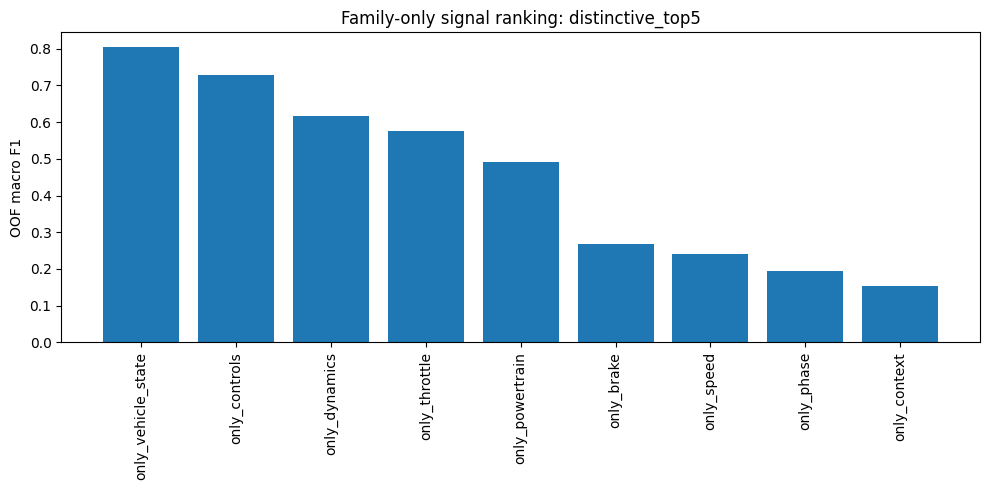

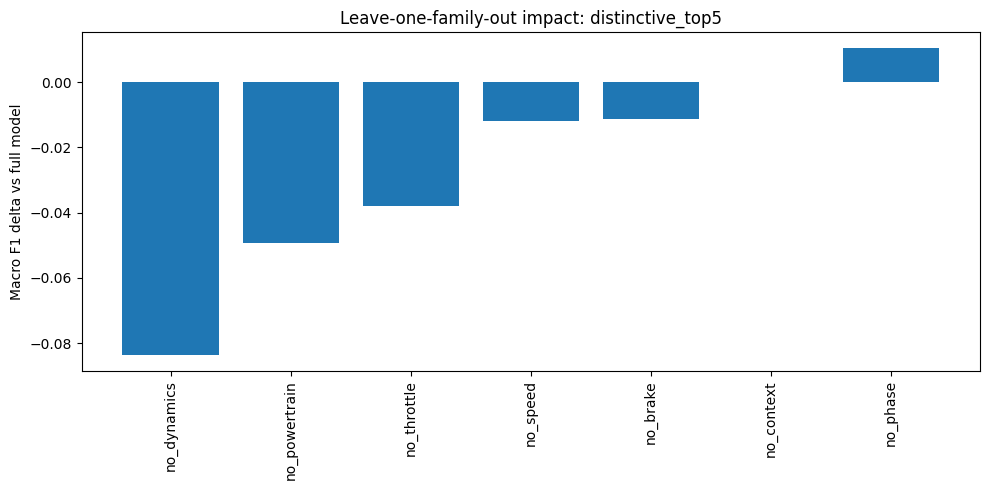

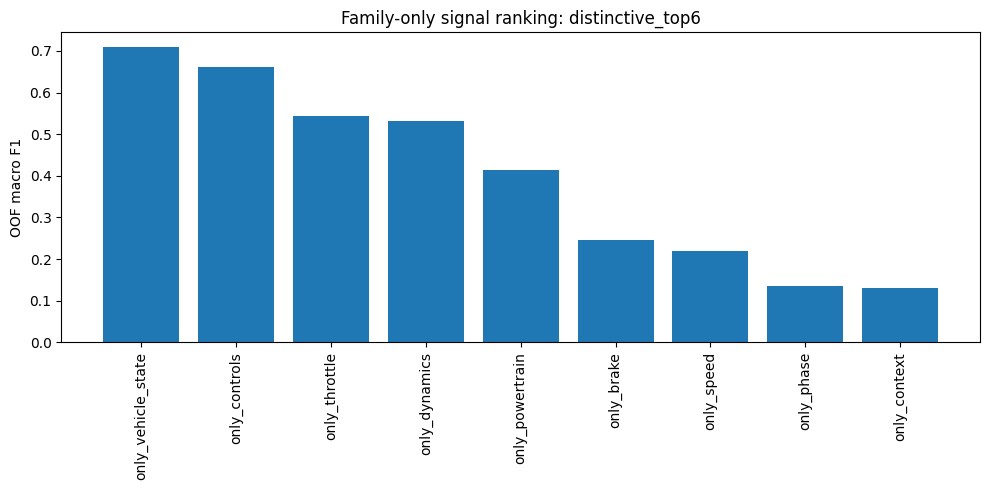

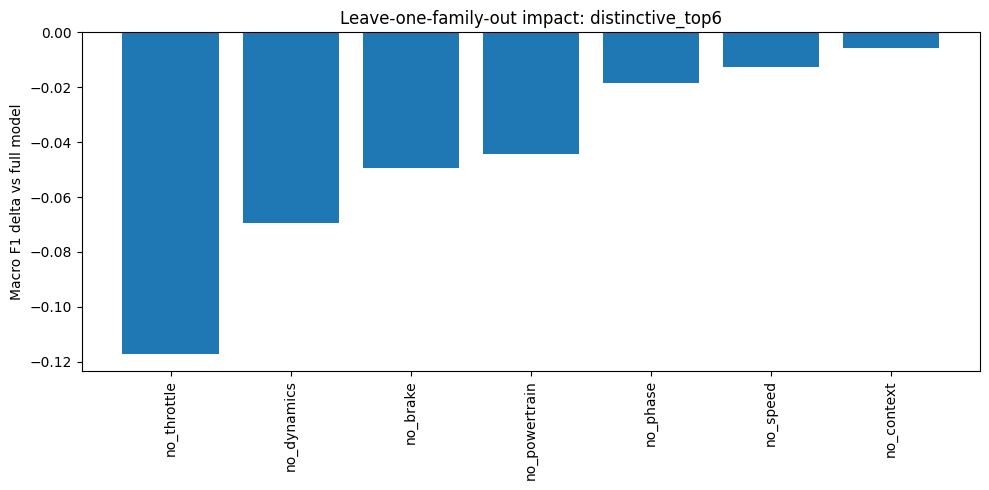

In [6]:
display(ablation_summary_df.sort_values(['subset_name', 'config_type', 'oof_macro_f1'], ascending=[True, True, False]))
display(family_only_rank_df)
display(leave_one_out_impact_df)

for subset_name in target_subsets:
    family_plot_df = family_only_rank_df[family_only_rank_df['subset_name'] == subset_name].copy()
    plt.figure(figsize=(10, 5))
    plt.bar(family_plot_df['config_name'], family_plot_df['oof_macro_f1'])
    plt.xticks(rotation=90)
    plt.ylabel('OOF macro F1')
    plt.title(f'Family-only signal ranking: {subset_name}')
    plt.tight_layout()
    plt.show()

    impact_plot_df = leave_one_out_impact_df[leave_one_out_impact_df['subset_name'] == subset_name].copy()
    plt.figure(figsize=(10, 5))
    plt.bar(impact_plot_df['config_name'], impact_plot_df['delta_oof_macro_f1_vs_full'])
    plt.xticks(rotation=90)
    plt.ylabel('Macro F1 delta vs full model')
    plt.title(f'Leave-one-family-out impact: {subset_name}')
    plt.tight_layout()
    plt.show()

## Interpretation Notes

- Strong family-only performance means a family can identify drivers by itself.
- A large drop in leave-one-family-out performance means that family adds unique information to the full model.
- If one family is weak alone but costly to remove, that suggests it works mainly in combination with others.

## Source: `10_compact_model_comparison.ipynb`


# 10 Compact Model Comparison

This notebook compares full and compact feature-set variants for the strongest reduced-driver setups.

Why this notebook exists:

- The ablation results showed that some feature families contribute little or even add noise.
- A compact model may keep almost all predictive performance while being easier to interpret and defend in the thesis.

Design:

- subsets: `distinctive_top5` and `distinctive_top6`
- model: tuned logistic regression from the previous notebook
- validation: grouped by qualifying session
- configs: full model, family-drop variants, and compact behavior-focused variants

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_logistic_pipeline(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight):
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", make_one_hot_encoder())]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    solver = "lbfgs" if penalty == "l2" else "saga"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        max_iter=7000,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def evaluate_config(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight, subset_name: str, config_name: str):
    X = df[feature_cols].copy()
    y = df["Driver"].copy()
    groups = df["session_key"].copy()
    cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

    fold_rows = []
    oof_pred = pd.Series(index=y.index, dtype="object")

    for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
        fitted = build_logistic_pipeline(df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
        X_train = X.iloc[train_idx]
        X_test = X.iloc[test_idx]
        y_train = y.iloc[train_idx]
        y_test = y.iloc[test_idx]

        fitted.fit(X_train, y_train)
        y_pred_train = fitted.predict(X_train)
        y_pred_test = fitted.predict(X_test)
        oof_pred.iloc[test_idx] = y_pred_test

        row = {
            "subset_name": subset_name,
            "config_name": config_name,
            "n_features": len(feature_cols),
            "fold": fold_idx,
        }
        row.update(score_split(y_train, y_pred_train, prefix="train"))
        row.update(score_split(y_test, y_pred_test, prefix="test"))
        row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
        row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
        fold_rows.append(row)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "subset_name": subset_name,
        "config_name": config_name,
        "n_features": len(feature_cols),
        "mean_train_accuracy": fold_df["train_accuracy"].mean(),
        "mean_test_accuracy": fold_df["test_accuracy"].mean(),
        "mean_accuracy_gap": fold_df["accuracy_gap"].mean(),
        "mean_train_macro_f1": fold_df["train_macro_f1"].mean(),
        "mean_test_macro_f1": fold_df["test_macro_f1"].mean(),
        "mean_macro_f1_gap": fold_df["macro_f1_gap"].mean(),
        "oof_accuracy": accuracy_score(y, oof_pred),
        "oof_balanced_accuracy": balanced_accuracy_score(y, oof_pred),
        "oof_macro_f1": f1_score(y, oof_pred, average="macro"),
    }
    return fold_df, summary

def fit_full_and_extract_coefficients(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight, subset_name: str, config_name: str):
    fitted = build_logistic_pipeline(df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
    fitted.fit(df[feature_cols], df["Driver"])
    preprocessor = fitted.named_steps["preprocess"]
    model = fitted.named_steps["model"]
    feature_names = preprocessor.get_feature_names_out()
    coef_abs_mean = np.abs(model.coef_).mean(axis=0)
    return pd.DataFrame(
        {
            "subset_name": subset_name,
            "config_name": config_name,
            "feature": feature_names,
            "importance": coef_abs_mean,
        }
    ).sort_values("importance", ascending=False)

In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
subset_defs_df = pd.read_csv(EXPORT_DIR / "subset_candidate_definitions.csv")
tuned_params_df = pd.read_csv(EXPORT_DIR / "logreg_tuning_best_params.csv")
feature_family_df = pd.read_csv(EXPORT_DIR / "feature_family_mapping.csv")

features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]
ALL_FEATURES = [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS]

feature_families = {
    family: feature_family_df[feature_family_df["family"] == family]["feature"].tolist()
    for family in feature_family_df["family"].unique()
}

controls_features = feature_families["throttle"] + feature_families["brake"] + feature_families["phase"]
core_behavior_features = feature_families["throttle"] + feature_families["brake"] + feature_families["powertrain"] + feature_families["dynamics"]
core_behavior_no_phase_features = feature_families["throttle"] + feature_families["brake"] + feature_families["powertrain"] + feature_families["dynamics"]

compact_configs = {
    "full_model": ALL_FEATURES,
    "compact_no_context": [c for c in ALL_FEATURES if c not in feature_families["context"]],
    "compact_no_context_no_phase": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["phase"]],
    "compact_no_context_no_speed": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["speed"]],
    "compact_no_context_no_phase_no_speed": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["phase"] + feature_families["speed"]],
    "compact_core_behavior": sorted(set(core_behavior_features)),
    "compact_controls_powertrain_dynamics": sorted(set(controls_features + feature_families["powertrain"] + feature_families["dynamics"])),
    "compact_vehicle_state": sorted(set(feature_families["speed"] + feature_families["powertrain"] + feature_families["dynamics"])),
    "compact_controls": sorted(set(controls_features)),
}

config_rows = []
for name, cols in compact_configs.items():
    config_rows.append({"config_name": name, "n_features": len(cols)})
compact_config_df = pd.DataFrame(config_rows).sort_values(["n_features", "config_name"]).reset_index(drop=True)
export_csv(compact_config_df, "compact_model_configurations")
display(compact_config_df)

,config_name,n_features
0,compact_controls,23
1,compact_vehicle_state,38
2,compact_core_behavior,46
3,compact_no_context_no_phase_no_speed,46
4,compact_controls_powertrain_dynamics,50
5,compact_no_context_no_speed,50
6,compact_no_context_no_phase,57
7,compact_no_context,61
8,full_model,64


In [4]:
target_subsets = ["distinctive_top5", "distinctive_top6"]

all_fold_frames = []
all_summary_rows = []
coef_frames = []

for subset_name in target_subsets:
    drivers = subset_defs_df[subset_defs_df["subset_name"] == subset_name]["driver"].tolist()
    subset_df = features_df[features_df["Driver"].isin(drivers)].copy()
    tuned_row = tuned_params_df[tuned_params_df["subset_name"] == subset_name].iloc[0]
    penalty = tuned_row["penalty"]
    C = float(tuned_row["C"])
    class_weight = None if tuned_row["class_weight"] == "none" else "balanced"

    print(f"Running compact comparison for {subset_name} with penalty={penalty}, C={C}, class_weight={tuned_row['class_weight']}")

    for config_name, feature_cols in compact_configs.items():
        fold_df, summary = evaluate_config(
            subset_df,
            feature_cols=feature_cols,
            penalty=penalty,
            C=C,
            class_weight=class_weight,
            subset_name=subset_name,
            config_name=config_name,
        )
        all_fold_frames.append(fold_df)
        all_summary_rows.append(summary)

compact_fold_metrics_df = pd.concat(all_fold_frames, ignore_index=True)
compact_summary_df = pd.DataFrame(all_summary_rows)

full_reference_df = compact_summary_df[compact_summary_df["config_name"] == "full_model"][['subset_name', 'oof_accuracy', 'oof_macro_f1', 'mean_accuracy_gap', 'mean_macro_f1_gap']].copy()
full_reference_df = full_reference_df.rename(columns={
    'oof_accuracy': 'full_oof_accuracy',
    'oof_macro_f1': 'full_oof_macro_f1',
    'mean_accuracy_gap': 'full_mean_accuracy_gap',
    'mean_macro_f1_gap': 'full_mean_macro_f1_gap',
})

compact_summary_df = compact_summary_df.merge(full_reference_df, on='subset_name', how='left')
compact_summary_df['delta_oof_accuracy_vs_full'] = compact_summary_df['oof_accuracy'] - compact_summary_df['full_oof_accuracy']
compact_summary_df['delta_oof_macro_f1_vs_full'] = compact_summary_df['oof_macro_f1'] - compact_summary_df['full_oof_macro_f1']
compact_summary_df['delta_accuracy_gap_vs_full'] = compact_summary_df['mean_accuracy_gap'] - compact_summary_df['full_mean_accuracy_gap']
compact_summary_df['delta_macro_f1_gap_vs_full'] = compact_summary_df['mean_macro_f1_gap'] - compact_summary_df['full_mean_macro_f1_gap']

recommended_rows = []
for subset_name, subset_summary in compact_summary_df.groupby('subset_name'):
        full_row = subset_summary[subset_summary['config_name'] == 'full_model'].iloc[0]
        chosen = None
        tolerance_used = None
        for tolerance in [0.005, 0.01, 0.02]:
            eligible = subset_summary[
                (subset_summary['delta_oof_macro_f1_vs_full'] >= -tolerance)
                & (subset_summary['config_name'] != 'full_model')
            ].sort_values(['n_features', 'oof_macro_f1'], ascending=[True, False])
            if not eligible.empty:
                chosen = eligible.iloc[0]
                tolerance_used = tolerance
                break
        if chosen is None:
            chosen = full_row
            tolerance_used = 0.0
        recommended_rows.append({
            'subset_name': subset_name,
            'recommended_config': chosen['config_name'],
            'recommended_n_features': int(chosen['n_features']),
            'recommended_oof_accuracy': chosen['oof_accuracy'],
            'recommended_oof_macro_f1': chosen['oof_macro_f1'],
            'delta_oof_accuracy_vs_full': chosen['delta_oof_accuracy_vs_full'],
            'delta_oof_macro_f1_vs_full': chosen['delta_oof_macro_f1_vs_full'],
            'tolerance_used': tolerance_used,
        })
        coef_df = fit_full_and_extract_coefficients(
            features_df[features_df['Driver'].isin(subset_defs_df[subset_defs_df['subset_name'] == subset_name]['driver'])].copy(),
            feature_cols=compact_configs[chosen['config_name']],
            penalty=penalty,
            C=C,
            class_weight=class_weight,
            subset_name=subset_name,
            config_name=chosen['config_name'],
        )
        coef_frames.append(coef_df)

recommended_compact_df = pd.DataFrame(recommended_rows)
recommended_feature_importance_df = pd.concat(coef_frames, ignore_index=True)

export_csv(compact_fold_metrics_df, 'compact_model_fold_metrics')
export_csv(compact_summary_df, 'compact_model_summary')
export_csv(recommended_compact_df, 'compact_model_recommendations')
export_csv(recommended_feature_importance_df, 'compact_model_recommended_feature_importance')

print('Exported:')
print('- exports/compact_model_configurations.csv')
print('- exports/compact_model_fold_metrics.csv')
print('- exports/compact_model_summary.csv')
print('- exports/compact_model_recommendations.csv')
print('- exports/compact_model_recommended_feature_importance.csv')

Running compact comparison for distinctive_top5 with penalty=l1, C=2.0, class_weight=none


Running compact comparison for distinctive_top6 with penalty=l2, C=1.0, class_weight=balanced


Exported:
- exports/compact_model_configurations.csv
- exports/compact_model_fold_metrics.csv
- exports/compact_model_summary.csv
- exports/compact_model_recommendations.csv
- exports/compact_model_recommended_feature_importance.csv


,subset_name,config_name,n_features,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1,full_oof_accuracy,full_oof_macro_f1,full_mean_accuracy_gap,full_mean_macro_f1_gap,delta_oof_accuracy_vs_full,delta_oof_macro_f1_vs_full,delta_accuracy_gap_vs_full,delta_macro_f1_gap_vs_full
2,distinctive_top5,compact_no_context_no_phase,57,0.989008,0.860741,0.128267,0.988906,0.860768,0.128138,0.860806,0.860741,0.861704,0.857143,0.858420,0.132753,0.131201,0.003663,0.003284,-0.004486,-0.003063
0,distinctive_top5,full_model,64,0.989925,0.857172,0.132753,0.989860,0.858659,0.131201,0.857143,0.856970,0.858420,0.857143,0.858420,0.132753,0.131201,0.000000,0.000000,0.000000,0.000000
1,distinctive_top5,compact_no_context,61,0.988094,0.857172,0.130923,0.988039,0.858844,0.129195,0.857143,0.856835,0.858371,0.857143,0.858420,0.132753,0.131201,0.000000,-0.000048,-0.001831,-0.002006
4,distinctive_top5,compact_no_context_no_phase_no_speed,46,0.983516,0.849832,0.133684,0.983469,0.850638,0.132831,0.849817,0.849697,0.850946,0.857143,0.858420,0.132753,0.131201,-0.007326,-0.007474,0.000931,0.001629
5,distinctive_top5,compact_core_behavior,46,0.983516,0.849832,0.133684,0.983469,0.850638,0.132831,0.849817,0.849697,0.850946,0.857143,0.858420,0.132753,0.131201,-0.007326,-0.007474,0.000931,0.001629
3,distinctive_top5,compact_no_context_no_speed,50,0.984433,0.835219,0.149214,0.984399,0.835678,0.148721,0.835165,0.834882,0.836030,0.857143,0.858420,0.132753,0.131201,-0.021978,-0.022389,0.016461,0.017520
6,distinctive_top5,compact_controls_powertrain_dynamics,50,0.984433,0.835219,0.149214,0.984399,0.835678,0.148721,0.835165,0.834882,0.836030,0.857143,0.858420,0.132753,0.131201,-0.021978,-0.022389,0.016461,0.017520
7,distinctive_top5,compact_vehicle_state,38,0.945964,0.805791,0.140172,0.945843,0.803371,0.142472,0.805861,0.805589,0.804675,0.857143,0.858420,0.132753,0.131201,-0.051282,-0.053745,0.007419,0.011270
8,distinctive_top5,compact_controls,23,0.777500,0.728956,0.048544,0.775582,0.727124,0.048459,0.728938,0.728485,0.728478,0.857143,0.858420,0.132753,0.131201,-0.128205,-0.129941,-0.084210,-0.082743
9,distinctive_top6,full_model,64,0.980126,0.831888,0.148238,0.980192,0.831450,0.148742,0.831804,0.831706,0.833021,0.831804,0.833021,0.148238,0.148742,0.000000,0.000000,0.000000,0.000000


,subset_name,recommended_config,recommended_n_features,recommended_oof_accuracy,recommended_oof_macro_f1,delta_oof_accuracy_vs_full,delta_oof_macro_f1_vs_full,tolerance_used
0,distinctive_top5,compact_no_context_no_phase,57,0.860806,0.861704,0.003663,0.003284,0.005
1,distinctive_top6,compact_no_context_no_phase_no_speed,46,0.825688,0.826851,-0.006116,-0.006170,0.010


,subset_name,config_name,feature,importance
0,distinctive_top5,compact_no_context_no_phase,num__gear_mean,1.036091
1,distinctive_top5,compact_no_context_no_phase,num__throttle_mid_frac,0.887161
2,distinctive_top5,compact_no_context_no_phase,num__throttle_diff_std,0.811216
3,distinctive_top5,compact_no_context_no_phase,num__throttle_diff_abs_mean,0.710422
4,distinctive_top5,compact_no_context_no_phase,num__throttle_zero_frac,0.708051
5,distinctive_top5,compact_no_context_no_phase,num__throttle_p10,0.559186
6,distinctive_top5,compact_no_context_no_phase,num__rpm_diff_std,0.527780
7,distinctive_top5,compact_no_context_no_phase,num__throttle_full_frac,0.517521
8,distinctive_top5,compact_no_context_no_phase,num__throttle_std,0.510525
9,distinctive_top5,compact_no_context_no_phase,num__rpm_diff_abs_mean,0.492020


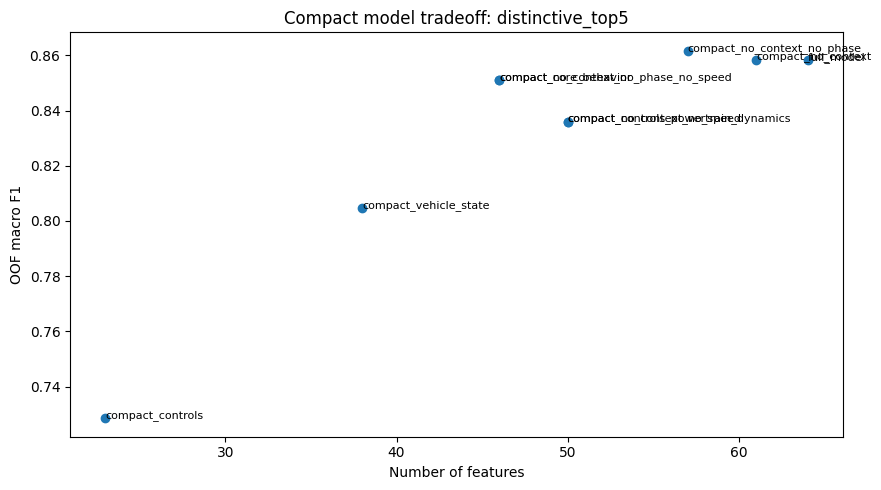

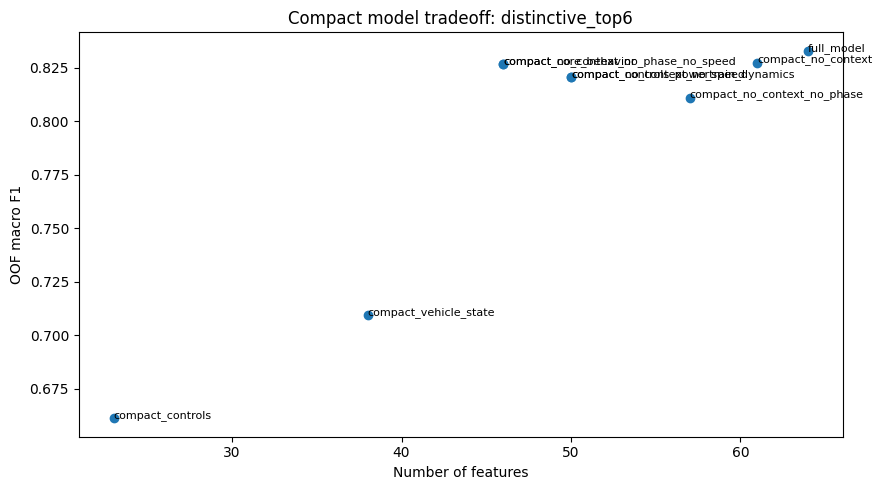

In [5]:
display(compact_summary_df.sort_values(['subset_name', 'oof_macro_f1', 'n_features'], ascending=[True, False, True]))
display(recommended_compact_df)
display(recommended_feature_importance_df.groupby('subset_name', as_index=False).head(20))

for subset_name in target_subsets:
    plot_df = compact_summary_df[compact_summary_df['subset_name'] == subset_name].copy().sort_values(['n_features', 'oof_macro_f1'])
    plt.figure(figsize=(9, 5))
    plt.scatter(plot_df['n_features'], plot_df['oof_macro_f1'])
    for _, row in plot_df.iterrows():
        plt.annotate(row['config_name'], (row['n_features'], row['oof_macro_f1']), fontsize=8)
    plt.xlabel('Number of features')
    plt.ylabel('OOF macro F1')
    plt.title(f'Compact model tradeoff: {subset_name}')
    plt.tight_layout()
    plt.show()

## Interpretation Notes

- The recommended compact model is the smallest config that stays close to the full model under grouped validation.
- If the recommended compact model removes weak families without hurting performance, that is a strong thesis result.
- If performance drops materially even after ablation-guided pruning, the full model remains the better main thesis model.

## Source: `11_final_compact_model_interpretation.ipynb`


# 11 Final Compact Model Interpretation

This notebook interprets the selected main handcrafted-feature model for the thesis.

Final model under interpretation:

- subset: `distinctive_top5`
- drivers: `ALB`, `SAI`, `VER`, `OCO`, `LEC`
- model family: tuned logistic regression
- feature set: recommended compact configuration from the compact-model comparison
- validation: grouped by qualifying session

Goals:

- quantify which drivers are easiest and hardest to identify,
- inspect the confusion structure,
- identify the telemetry features that most drive classification,
- export thesis-ready CSV outputs for later reporting.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5
TARGET_SUBSET = "distinctive_top5"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def make_one_hot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def build_logistic_pipeline(df: pd.DataFrame, feature_cols, penalty: str, C: float, class_weight):
    categorical_cols = [c for c in feature_cols if df[c].dtype == "object"]
    numeric_cols = [c for c in feature_cols if c not in categorical_cols]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", make_one_hot_encoder())]),
                categorical_cols,
            ),
        ],
        remainder="drop",
    )

    solver = "lbfgs" if penalty == "l2" else "saga"
    model = LogisticRegression(
        penalty=penalty,
        C=C,
        solver=solver,
        max_iter=7000,
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )

    return Pipeline(steps=[("preprocess", preprocessor), ("model", model)])

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }


In [3]:
features_df = pd.read_csv(EXPORT_DIR / "lap_features_model_min_40_laps.csv")
subset_defs_df = pd.read_csv(EXPORT_DIR / "subset_candidate_definitions.csv")
tuned_params_df = pd.read_csv(EXPORT_DIR / "logreg_tuning_best_params.csv")
compact_recommendations_df = pd.read_csv(EXPORT_DIR / "compact_model_recommendations.csv")
feature_family_df = pd.read_csv(EXPORT_DIR / "feature_family_mapping.csv")

features_df["session_key"] = features_df["season"].astype(str) + "_" + features_df["round"].astype(str)

BASE_EXCLUDED_COLS = [
    "lap_key",
    "Driver",
    "session_key",
    "season",
    "round",
    "LapNumber",
    "Team",
    "throttle_min",
    "brake_min",
    "brake_median",
    "brake_hard_frac",
    "drs_toggle_count",
    "brake_diff_mean",
    "drs_active_frac",
    "LapTimeSeconds",
    "Sector1TimeSeconds",
    "Sector2TimeSeconds",
    "Sector3TimeSeconds",
    "sector_sum_seconds",
    "sector1_share",
    "sector2_share",
    "sector3_share",
]
ALL_FEATURES = [c for c in features_df.columns if c not in BASE_EXCLUDED_COLS]

feature_families = {
    family: feature_family_df[feature_family_df["family"] == family]["feature"].tolist()
    for family in feature_family_df["family"].unique()
}

compact_configs = {
    "full_model": ALL_FEATURES,
    "compact_no_context": [c for c in ALL_FEATURES if c not in feature_families["context"]],
    "compact_no_context_no_phase": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["phase"]],
    "compact_no_context_no_speed": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["speed"]],
    "compact_no_context_no_phase_no_speed": [c for c in ALL_FEATURES if c not in feature_families["context"] + feature_families["phase"] + feature_families["speed"]],
    "compact_core_behavior": sorted(set(feature_families["throttle"] + feature_families["brake"] + feature_families["powertrain"] + feature_families["dynamics"])),
    "compact_controls_powertrain_dynamics": sorted(set(feature_families["throttle"] + feature_families["brake"] + feature_families["phase"] + feature_families["powertrain"] + feature_families["dynamics"])),
    "compact_vehicle_state": sorted(set(feature_families["speed"] + feature_families["powertrain"] + feature_families["dynamics"])),
    "compact_controls": sorted(set(feature_families["throttle"] + feature_families["brake"] + feature_families["phase"])),
}

drivers = subset_defs_df[subset_defs_df["subset_name"] == TARGET_SUBSET]["driver"].tolist()
subset_df = features_df[features_df["Driver"].isin(drivers)].copy()

tuned_row = tuned_params_df[tuned_params_df["subset_name"] == TARGET_SUBSET].iloc[0]
recommendation_row = compact_recommendations_df[compact_recommendations_df["subset_name"] == TARGET_SUBSET].iloc[0]

penalty = tuned_row["penalty"]
C = float(tuned_row["C"])
class_weight = None if tuned_row["class_weight"] == "none" else "balanced"
config_name = recommendation_row["recommended_config"]
feature_cols = compact_configs[config_name]

final_model_config_df = pd.DataFrame(
    [
        {
            "subset_name": TARGET_SUBSET,
            "drivers": ", ".join(drivers),
            "config_name": config_name,
            "n_features": len(feature_cols),
            "penalty": penalty,
            "C": C,
            "class_weight": tuned_row["class_weight"],
        }
    ]
)
export_csv(final_model_config_df, "final_model_config")

display(final_model_config_df)

,subset_name,drivers,config_name,n_features,penalty,C,class_weight
0,distinctive_top5,"ALB, SAI, VER, OCO, LEC",compact_no_context_no_phase,57,l1,2.0,none


In [4]:
X = subset_df[feature_cols].copy()
y = subset_df["Driver"].copy()
groups = subset_df["session_key"].copy()
labels = sorted(y.unique())
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
oof_pred = pd.Series(index=y.index, dtype="object")
oof_max_proba = pd.Series(index=y.index, dtype=float)
oof_true_class_proba = pd.Series(index=y.index, dtype=float)

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups), start=1):
    fitted = build_logistic_pipeline(subset_df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    fitted.fit(X_train, y_train)
    y_pred_train = fitted.predict(X_train)
    y_pred_test = fitted.predict(X_test)
    y_proba_test = fitted.predict_proba(X_test)
    class_to_idx = {cls: i for i, cls in enumerate(fitted.named_steps["model"].classes_)}

    oof_pred.iloc[test_idx] = y_pred_test
    oof_max_proba.iloc[test_idx] = y_proba_test.max(axis=1)
    oof_true_class_proba.iloc[test_idx] = [y_proba_test[i, class_to_idx[label]] for i, label in enumerate(y_test)]

    row = {
        "fold": fold_idx,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "train_groups": groups.iloc[train_idx].nunique(),
        "test_groups": groups.iloc[test_idx].nunique(),
    }
    row.update(score_split(y_train, y_pred_train, prefix="train"))
    row.update(score_split(y_test, y_pred_test, prefix="test"))
    row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
    row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
    fold_rows.append(row)

final_model_fold_metrics_df = pd.DataFrame(fold_rows)
final_model_oof_df = pd.DataFrame(
    {
        "lap_key": subset_df["lap_key"],
        "session_key": subset_df["session_key"],
        "true_driver": y,
        "pred_driver": oof_pred,
        "pred_confidence": oof_max_proba,
        "true_class_probability": oof_true_class_proba,
        "is_correct": y == oof_pred,
    }
)

export_csv(final_model_fold_metrics_df, "final_model_fold_metrics")
export_csv(final_model_oof_df, "final_model_oof_predictions")

display(final_model_fold_metrics_df)
display(final_model_oof_df.head())

,fold,n_train,n_test,train_groups,test_groups,train_accuracy,train_balanced_accuracy,train_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,accuracy_gap,macro_f1_gap
0,1,218,55,44,11,0.986239,0.986047,0.986043,0.854545,0.854545,0.856883,0.131693,0.129160
1,2,218,55,44,11,0.986239,0.986047,0.985978,0.872727,0.872727,0.873281,0.113511,0.112698
2,3,218,55,44,11,0.990826,0.990803,0.990803,0.872727,0.872727,0.875664,0.118098,0.115138
3,4,219,54,44,11,0.995434,0.995455,0.995454,0.833333,0.834545,0.828750,0.162100,0.166704
4,5,219,54,44,11,0.986301,0.986258,0.986253,0.870370,0.869091,0.869264,0.115931,0.116989


,lap_key,session_key,true_driver,pred_driver,pred_confidence,true_class_probability,is_correct
0,2023_1_ALB_5.0,2023_1,ALB,ALB,0.987622,0.987622,True
5,2023_1_LEC_16.0,2023_1,LEC,LEC,0.813687,0.813687,True
7,2023_1_OCO_11.0,2023_1,OCO,OCO,0.973234,0.973234,True
10,2023_1_SAI_17.0,2023_1,SAI,SAI,0.988510,0.988510,True
13,2023_1_VER_14.0,2023_1,VER,VER,0.960423,0.960423,True


In [5]:
per_driver_rows = []
for driver in labels:
    mask_true = final_model_oof_df["true_driver"] == driver
    y_true_binary = mask_true.astype(int)
    y_pred_binary = (final_model_oof_df["pred_driver"] == driver).astype(int)
    correct_mask = (final_model_oof_df["true_driver"] == driver) & (final_model_oof_df["is_correct"])
    incorrect_mask = (final_model_oof_df["true_driver"] == driver) & (~final_model_oof_df["is_correct"])

    per_driver_rows.append(
        {
            "driver": driver,
            "n_samples": int(mask_true.sum()),
            "precision": precision_score(y_true_binary, y_pred_binary, zero_division=0),
            "recall": recall_score(y_true_binary, y_pred_binary, zero_division=0),
            "f1": f1_score(y_true_binary, y_pred_binary, zero_division=0),
            "mean_pred_confidence": final_model_oof_df.loc[mask_true, "pred_confidence"].mean(),
            "mean_true_class_probability": final_model_oof_df.loc[mask_true, "true_class_probability"].mean(),
            "mean_confidence_when_correct": final_model_oof_df.loc[correct_mask, "pred_confidence"].mean(),
            "mean_confidence_when_incorrect": final_model_oof_df.loc[incorrect_mask, "pred_confidence"].mean(),
        }
    )

final_model_per_driver_metrics_df = pd.DataFrame(per_driver_rows).sort_values("recall", ascending=False).reset_index(drop=True)

conf = confusion_matrix(final_model_oof_df["true_driver"], final_model_oof_df["pred_driver"], labels=labels)
conf_df = pd.DataFrame(conf, index=labels, columns=labels)
conf_long_df = conf_df.stack().reset_index()
conf_long_df.columns = ["true_driver", "pred_driver", "count"]
row_sums = conf_df.sum(axis=1)
conf_long_df["row_normalized"] = conf_long_df.apply(lambda r: r["count"] / row_sums.loc[r["true_driver"]] if row_sums.loc[r["true_driver"]] > 0 else np.nan, axis=1)

misclassified_pairs_df = (
    final_model_oof_df[~final_model_oof_df["is_correct"]]
    .groupby(["true_driver", "pred_driver"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

export_csv(final_model_per_driver_metrics_df, "final_model_per_driver_metrics")
export_csv(conf_long_df, "final_model_confusion_matrix")
export_csv(misclassified_pairs_df, "final_model_misclassified_pairs")

display(final_model_per_driver_metrics_df)
display(misclassified_pairs_df)

,driver,n_samples,precision,recall,f1,mean_pred_confidence,mean_true_class_probability,mean_confidence_when_correct,mean_confidence_when_incorrect
0,VER,55,0.944444,0.927273,0.935780,0.910919,0.872485,0.925906,0.719834
1,LEC,55,0.942308,0.890909,0.915888,0.918440,0.858568,0.945186,0.700017
2,OCO,54,0.886792,0.870370,0.878505,0.867928,0.792817,0.901864,0.640075
3,SAI,54,0.775862,0.833333,0.803571,0.859950,0.749298,0.873041,0.794491
4,ALB,55,0.767857,0.781818,0.774775,0.830931,0.739197,0.887967,0.626552


,true_driver,pred_driver,count
0,ALB,SAI,5
1,LEC,SAI,5
2,SAI,ALB,5
3,VER,ALB,4
4,OCO,ALB,4
5,OCO,SAI,3
6,ALB,OCO,3
7,ALB,VER,3
8,SAI,OCO,2
9,SAI,LEC,2


In [6]:
fitted_full = build_logistic_pipeline(subset_df, feature_cols, penalty=penalty, C=C, class_weight=class_weight)
fitted_full.fit(X, y)

preprocessor = fitted_full.named_steps["preprocess"]
model = fitted_full.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()
classes = model.classes_
coef_matrix = model.coef_

global_importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_coef": np.abs(coef_matrix).mean(axis=0),
    }
).sort_values("mean_abs_coef", ascending=False)

by_driver_rows = []
for class_idx, driver in enumerate(classes):
    for feat_idx, feat_name in enumerate(feature_names):
        by_driver_rows.append(
            {
                "driver": driver,
                "feature": feat_name,
                "coef": coef_matrix[class_idx, feat_idx],
                "abs_coef": abs(coef_matrix[class_idx, feat_idx]),
            }
        )
final_model_feature_importance_by_driver_df = pd.DataFrame(by_driver_rows).sort_values(["driver", "abs_coef"], ascending=[True, False])

top_driver_features_df = final_model_feature_importance_by_driver_df.groupby("driver", as_index=False).head(15).reset_index(drop=True)

selected_feature_df = subset_df[["Driver"] + feature_cols].copy()
numeric_features = [c for c in feature_cols if pd.api.types.is_numeric_dtype(selected_feature_df[c])]
z_df = selected_feature_df.copy()
for col in numeric_features:
    std = z_df[col].std()
    if pd.notna(std) and std > 0:
        z_df[col] = (z_df[col] - z_df[col].mean()) / std
    else:
        z_df[col] = 0.0
driver_profile_df = z_df.groupby("Driver")[numeric_features].mean().reset_index()

profile_rows = []
for _, row in driver_profile_df.iterrows():
    driver = row["Driver"]
    temp = pd.DataFrame(
        {
            "driver": driver,
            "feature": numeric_features,
            "mean_zscore": [row[f] for f in numeric_features],
        }
    )
    temp["abs_mean_zscore"] = temp["mean_zscore"].abs()
    profile_rows.append(temp.sort_values("abs_mean_zscore", ascending=False).head(15))
driver_profile_top_df = pd.concat(profile_rows, ignore_index=True)

export_csv(global_importance_df, "final_model_feature_importance_global")
export_csv(final_model_feature_importance_by_driver_df, "final_model_feature_importance_by_driver")
export_csv(driver_profile_df, "final_model_driver_feature_profile")
export_csv(driver_profile_top_df, "final_model_driver_feature_profile_top")

display(global_importance_df.head(25))
display(top_driver_features_df)
display(driver_profile_top_df)

,feature,mean_abs_coef
18,num__gear_mean,2.229861
36,num__throttle_diff_std,1.237340
37,num__throttle_diff_abs_mean,1.144716
23,num__throttle_zero_frac,1.022427
25,num__throttle_mid_frac,0.974064
1,num__speed_std,0.720095
43,num__rpm_diff_std,0.635473
44,num__rpm_diff_abs_mean,0.625347
27,num__throttle_full_frac,0.603179
17,num__rpm_median,0.517659


,driver,feature,coef,abs_coef
0,ALB,num__gear_mean,5.386983,5.386983
1,ALB,num__throttle_full_frac,-2.725185,2.725185
2,ALB,num__throttle_p25,-2.490699,2.490699
3,ALB,num__throttle_diff_abs_mean,-1.734110,1.734110
4,ALB,num__speed_p10,1.520629,1.520629
...,...,...,...,...
70,VER,num__gear_change_count,-0.299356,0.299356
71,VER,num__speed_diff_mean,-0.249355,0.249355
72,VER,num__throttle_median,0.107716,0.107716
73,VER,num__brake_on_count,-0.090026,0.090026


,driver,feature,mean_zscore,abs_mean_zscore
0,ALB,rpm_max,0.663715,0.663715
1,ALB,throttle_zero_frac,0.468413,0.468413
2,ALB,throttle_p75,0.437534,0.437534
3,ALB,throttle_diff_abs_max,0.397877,0.397877
4,ALB,throttle_p10,-0.355747,0.355747
...,...,...,...,...
70,VER,throttle_p10,-0.379358,0.379358
71,VER,throttle_p90,0.337442,0.337442
72,VER,brake_std,-0.333489,0.333489
73,VER,brake_mean,-0.326771,0.326771


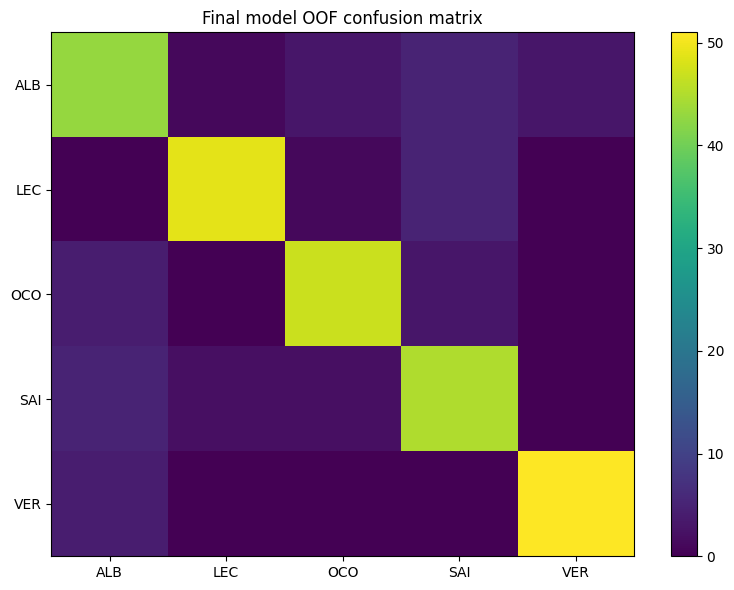

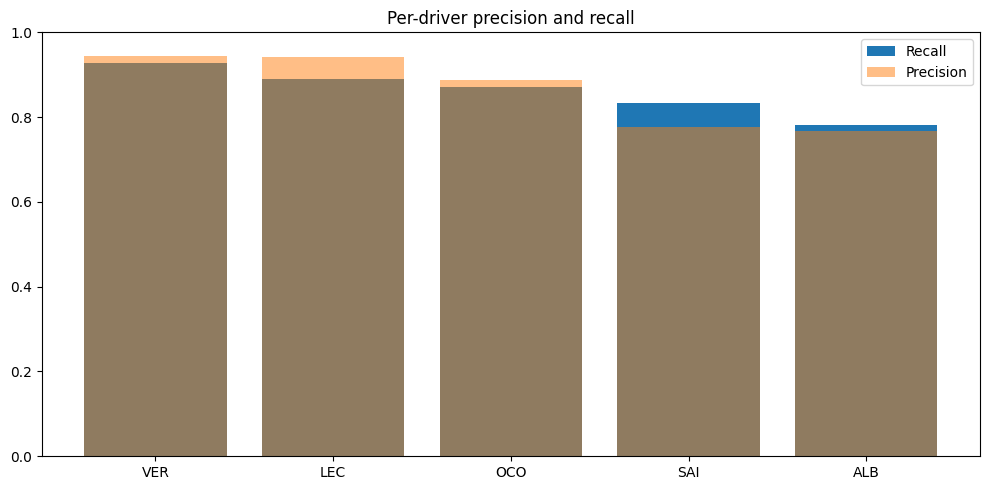

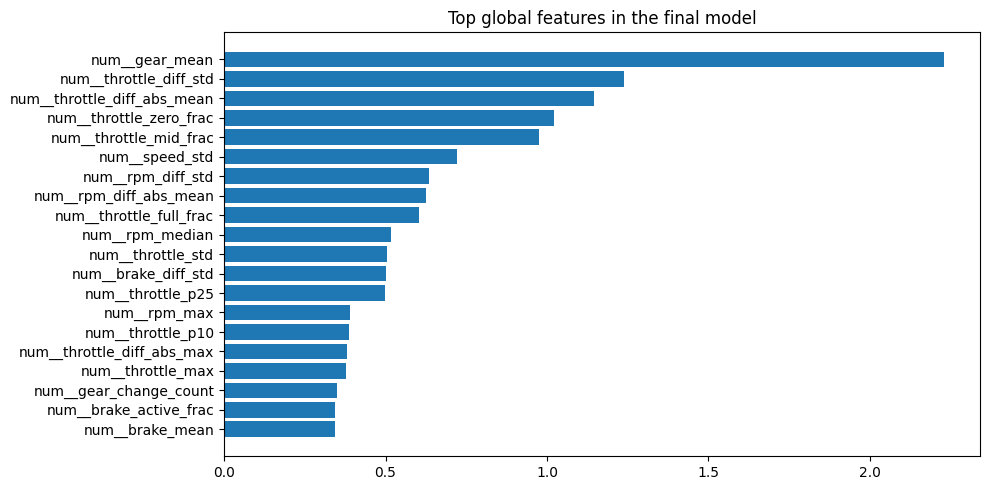

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_df, aspect="auto")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.title("Final model OOF confusion matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_df = final_model_per_driver_metrics_df.sort_values("recall", ascending=False)
x = np.arange(len(plot_df))
plt.bar(x, plot_df["recall"], label="Recall")
plt.bar(x, plot_df["precision"], alpha=0.5, label="Precision")
plt.xticks(x, plot_df["driver"])
plt.ylim(0, 1)
plt.title("Per-driver precision and recall")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
top_global = global_importance_df.head(20)
plt.barh(top_global["feature"][::-1], top_global["mean_abs_coef"][::-1])
plt.title("Top global features in the final model")
plt.tight_layout()
plt.show()

## Interpretation Notes

- The per-driver metrics show which styles are most consistently recognizable in the final setup.
- The confusion matrix shows where the model still sees overlap between drivers.
- The coefficient tables show which telemetry patterns push the classifier toward each driver class.
- The driver profile table is useful for qualitative discussion, but it should be interpreted as descriptive support rather than direct causal proof.

## Source: `12_sequence_model_baseline.ipynb`


# 12 Sequence Model Baseline

This notebook builds the first sequence-based comparison against the final handcrafted-feature model.

Design choices:

- driver subset: `distinctive_top5`
- sequence source: whole-lap telemetry from `best_laps_telemetry_merged.csv`
- channels: `Speed`, `Throttle`, `Brake`, `RPM`, `nGear`
- sequence preparation: resample each lap to a fixed number of normalized progress points
- model: 1D CNN classifier
- validation: grouped by qualifying session

Important scope note:

- Position channels are intentionally excluded here because the current car-position merge is not precise enough for fine spatial interpretation and could amplify track/context leakage.
- This is the first sequence baseline, not the final possible sequence architecture.

In [1]:
from pathlib import Path
import os
import random
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

EXPORT_DIR = Path("exports")
RANDOM_STATE = 42
N_SPLITS = 5
SEQ_LEN = 300
CHANNELS = ["Speed", "Throttle", "Brake", "RPM", "nGear"]
TARGET_SUBSET = "distinctive_top5"

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

tf.keras.utils.set_random_seed(RANDOM_STATE)

In [2]:
def export_csv(df: pd.DataFrame, name: str) -> Path:
    path = EXPORT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    return path

def resample_sequence(values: np.ndarray, target_len: int) -> np.ndarray:
    values = pd.Series(values).astype(float)
    values = values.interpolate(limit_direction="both").fillna(method="bfill").fillna(method="ffill")
    values = values.to_numpy(dtype=float)
    n = len(values)
    if n == 0:
        return np.full(target_len, np.nan)
    if n == 1:
        return np.repeat(values[0], target_len)
    x_old = np.linspace(0.0, 1.0, n)
    x_new = np.linspace(0.0, 1.0, target_len)
    return np.interp(x_new, x_old, values)

def build_cnn_model(seq_len: int, n_channels: int, n_classes: int) -> tf.keras.Model:
    inputs = tf.keras.Input(shape=(seq_len, n_channels))
    x = tf.keras.layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(inputs)
    x = tf.keras.layers.Conv1D(32, kernel_size=7, padding="same", activation="relu")(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.2)(x)

    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding="same", activation="relu")(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(n_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def score_split(y_true, y_pred, prefix: str):
    return {
        f"{prefix}_accuracy": accuracy_score(y_true, y_pred),
        f"{prefix}_balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        f"{prefix}_macro_f1": f1_score(y_true, y_pred, average="macro"),
    }

def standardize_by_train(train_x: np.ndarray, val_x: np.ndarray, test_x: np.ndarray):
    mean = train_x.reshape(-1, train_x.shape[-1]).mean(axis=0)
    std = train_x.reshape(-1, train_x.shape[-1]).std(axis=0)
    std = np.where(std > 0, std, 1.0)
    train_scaled = (train_x - mean) / std
    val_scaled = (val_x - mean) / std
    test_scaled = (test_x - mean) / std
    return train_scaled, val_scaled, test_scaled, mean, std

In [3]:
telemetry_df = pd.read_csv(
    EXPORT_DIR / "best_laps_telemetry_merged.csv",
    usecols=["lap_key", "season", "round", "Driver", "sample_idx"] + CHANNELS,
)
subset_defs_df = pd.read_csv(EXPORT_DIR / "subset_candidate_definitions.csv")
compact_recommendations_df = pd.read_csv(EXPORT_DIR / "compact_model_recommendations.csv")

drivers = subset_defs_df[subset_defs_df["subset_name"] == TARGET_SUBSET]["driver"].tolist()
telemetry_df = telemetry_df[telemetry_df["Driver"].isin(drivers)].copy()
telemetry_df["session_key"] = telemetry_df["season"].astype(str) + "_" + telemetry_df["round"].astype(str)
telemetry_df["Brake"] = (
    telemetry_df["Brake"].astype(str).str.lower().map({"true": 1.0, "false": 0.0})
)

lap_rows = []
sequence_arrays = []

for lap_key, lap_df in telemetry_df.sort_values(["lap_key", "sample_idx"]).groupby("lap_key"):
    lap_meta = lap_df.iloc[0]
    channel_matrix = []
    for channel in CHANNELS:
        series = pd.to_numeric(lap_df[channel], errors="coerce").astype(float).values
        channel_matrix.append(resample_sequence(series, SEQ_LEN))
    sequence_arrays.append(np.stack(channel_matrix, axis=-1))
    lap_rows.append(
        {
            "lap_key": lap_key,
            "Driver": lap_meta["Driver"],
            "season": int(lap_meta["season"]),
            "round": int(lap_meta["round"]),
            "session_key": lap_meta["session_key"],
            "raw_len": len(lap_df),
        }
    )

sequence_meta_df = pd.DataFrame(lap_rows)
X_seq = np.stack(sequence_arrays).astype(np.float32)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(sequence_meta_df["Driver"])
groups = sequence_meta_df["session_key"].values

sequence_data_summary_df = pd.DataFrame(
    [
        {
            "n_laps": len(sequence_meta_df),
            "n_drivers": sequence_meta_df["Driver"].nunique(),
            "n_sessions": sequence_meta_df["session_key"].nunique(),
            "seq_len": SEQ_LEN,
            "n_channels": len(CHANNELS),
            "raw_len_mean": sequence_meta_df["raw_len"].mean(),
            "raw_len_median": sequence_meta_df["raw_len"].median(),
            "raw_len_min": sequence_meta_df["raw_len"].min(),
            "raw_len_max": sequence_meta_df["raw_len"].max(),
            "channels": ", ".join(CHANNELS),
        }
    ]
)
sequence_driver_counts_df = sequence_meta_df["Driver"].value_counts().sort_index().rename_axis("Driver").reset_index(name="n_laps")

export_csv(sequence_data_summary_df, "sequence_data_summary")
export_csv(sequence_driver_counts_df, "sequence_driver_counts")

display(sequence_data_summary_df)
display(sequence_driver_counts_df)

,n_laps,n_drivers,n_sessions,seq_len,n_channels,raw_len_mean,raw_len_median,raw_len_min,raw_len_max,channels
0,273,5,55,300,5,310.564103,316.0,236,399,"Speed, Throttle, Brake, RPM, nGear"


,Driver,n_laps
0,ALB,55
1,LEC,55
2,OCO,54
3,SAI,54
4,VER,55


In [4]:
cv = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

fold_rows = []
oof_pred = np.empty(len(y), dtype=int)
oof_pred.fill(-1)
oof_max_proba = np.full(len(y), np.nan)
oof_true_class_proba = np.full(len(y), np.nan)
history_rows = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_seq, y, groups), start=1):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE + fold_idx)

    X_train_full = X_seq[train_idx]
    y_train_full = y[train_idx]
    train_groups_full = groups[train_idx]
    X_test = X_seq[test_idx]
    y_test = y[test_idx]

    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE + fold_idx)
    train_inner_idx, val_idx = next(gss.split(X_train_full, y_train_full, groups=train_groups_full))

    X_train = X_train_full[train_inner_idx]
    y_train = y_train_full[train_inner_idx]
    X_val = X_train_full[val_idx]
    y_val = y_train_full[val_idx]

    X_train, X_val, X_test_scaled, channel_mean, channel_std = standardize_by_train(X_train, X_val, X_test)
    X_train_full_scaled = (X_train_full - channel_mean) / channel_std

    model = build_cnn_model(seq_len=SEQ_LEN, n_channels=len(CHANNELS), n_classes=len(label_encoder.classes_))
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=16,
        verbose=0,
        callbacks=callbacks,
    )

    test_proba = model.predict(X_test_scaled, verbose=0)
    test_pred = test_proba.argmax(axis=1)

    train_full_proba = model.predict(X_train_full_scaled, verbose=0)
    train_full_pred = train_full_proba.argmax(axis=1)

    oof_pred[test_idx] = test_pred
    oof_max_proba[test_idx] = test_proba.max(axis=1)
    oof_true_class_proba[test_idx] = test_proba[np.arange(len(y_test)), y_test]

    row = {
        "fold": fold_idx,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_train_inner": len(train_inner_idx),
        "n_val": len(val_idx),
        "train_groups": len(np.unique(groups[train_idx])),
        "test_groups": len(np.unique(groups[test_idx])),
        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": float(np.min(history.history["val_loss"])),
    }
    row.update(score_split(y_train_full, train_full_pred, prefix="train"))
    row.update(score_split(y_test, test_pred, prefix="test"))
    row["accuracy_gap"] = row["train_accuracy"] - row["test_accuracy"]
    row["macro_f1_gap"] = row["train_macro_f1"] - row["test_macro_f1"]
    fold_rows.append(row)

    for epoch_idx, (loss, val_loss, acc, val_acc) in enumerate(zip(history.history["loss"], history.history["val_loss"], history.history["accuracy"], history.history["val_accuracy"]), start=1):
        history_rows.append(
            {
                "fold": fold_idx,
                "epoch": epoch_idx,
                "loss": float(loss),
                "val_loss": float(val_loss),
                "accuracy": float(acc),
                "val_accuracy": float(val_acc),
            }
        )

sequence_cnn_fold_metrics_df = pd.DataFrame(fold_rows)
sequence_cnn_history_df = pd.DataFrame(history_rows)
oof_pred_labels = label_encoder.inverse_transform(oof_pred)
true_labels = label_encoder.inverse_transform(y)

sequence_cnn_oof_df = pd.DataFrame(
    {
        "lap_key": sequence_meta_df["lap_key"],
        "session_key": sequence_meta_df["session_key"],
        "true_driver": true_labels,
        "pred_driver": oof_pred_labels,
        "pred_confidence": oof_max_proba,
        "true_class_probability": oof_true_class_proba,
        "is_correct": true_labels == oof_pred_labels,
    }
)

sequence_cnn_summary_df = pd.DataFrame(
    [
        {
            "model": "sequence_1d_cnn",
            "n_samples": len(y),
            "n_drivers": len(label_encoder.classes_),
            "seq_len": SEQ_LEN,
            "n_channels": len(CHANNELS),
            "mean_train_accuracy": sequence_cnn_fold_metrics_df["train_accuracy"].mean(),
            "mean_test_accuracy": sequence_cnn_fold_metrics_df["test_accuracy"].mean(),
            "mean_accuracy_gap": sequence_cnn_fold_metrics_df["accuracy_gap"].mean(),
            "mean_train_macro_f1": sequence_cnn_fold_metrics_df["train_macro_f1"].mean(),
            "mean_test_macro_f1": sequence_cnn_fold_metrics_df["test_macro_f1"].mean(),
            "mean_macro_f1_gap": sequence_cnn_fold_metrics_df["macro_f1_gap"].mean(),
            "oof_accuracy": accuracy_score(true_labels, oof_pred_labels),
            "oof_balanced_accuracy": balanced_accuracy_score(true_labels, oof_pred_labels),
            "oof_macro_f1": f1_score(true_labels, oof_pred_labels, average="macro"),
        }
    ]
)

export_csv(sequence_cnn_fold_metrics_df, "sequence_cnn_fold_metrics")
export_csv(sequence_cnn_history_df, "sequence_cnn_training_history")
export_csv(sequence_cnn_oof_df, "sequence_cnn_oof_predictions")
export_csv(sequence_cnn_summary_df, "sequence_cnn_summary")

display(sequence_cnn_summary_df)
display(sequence_cnn_fold_metrics_df)

,model,n_samples,n_drivers,seq_len,n_channels,mean_train_accuracy,mean_test_accuracy,mean_accuracy_gap,mean_train_macro_f1,mean_test_macro_f1,mean_macro_f1_gap,oof_accuracy,oof_balanced_accuracy,oof_macro_f1
0,sequence_1d_cnn,273,5,300,5,0.967019,0.87569,0.091328,0.9668,0.872906,0.093894,0.875458,0.874815,0.873154


,fold,n_train,n_test,n_train_inner,n_val,train_groups,test_groups,epochs_trained,best_val_loss,train_accuracy,train_balanced_accuracy,train_macro_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,accuracy_gap,macro_f1_gap
0,1,218,55,173,45,44,11,95,0.265013,0.949541,0.949154,0.949269,0.872727,0.872727,0.869207,0.076814,0.080062
1,2,218,55,173,45,44,11,85,0.163184,0.963303,0.962896,0.962668,0.818182,0.818182,0.817154,0.145121,0.145514
2,3,218,55,173,45,44,11,80,0.386250,0.972477,0.972199,0.972376,0.872727,0.872727,0.871636,0.099750,0.100740
3,4,219,54,174,45,44,11,112,0.124838,0.963470,0.963531,0.963382,0.888889,0.885455,0.884685,0.074581,0.078697
4,5,219,54,174,45,44,11,93,0.236522,0.986301,0.986258,0.986304,0.925926,0.921818,0.921849,0.060375,0.064456


In [5]:
per_driver_rows = []
for driver in label_encoder.classes_:
    mask_true = sequence_cnn_oof_df["true_driver"] == driver
    y_true_binary = mask_true.astype(int)
    y_pred_binary = (sequence_cnn_oof_df["pred_driver"] == driver).astype(int)
    per_driver_rows.append(
        {
            "driver": driver,
            "n_samples": int(mask_true.sum()),
            "precision": precision_score(y_true_binary, y_pred_binary, zero_division=0),
            "recall": recall_score(y_true_binary, y_pred_binary, zero_division=0),
            "f1": f1_score(y_true_binary, y_pred_binary, zero_division=0),
            "mean_pred_confidence": sequence_cnn_oof_df.loc[mask_true, "pred_confidence"].mean(),
            "mean_true_class_probability": sequence_cnn_oof_df.loc[mask_true, "true_class_probability"].mean(),
        }
    )

sequence_cnn_per_driver_df = pd.DataFrame(per_driver_rows).sort_values("recall", ascending=False).reset_index(drop=True)

labels = list(label_encoder.classes_)
conf = confusion_matrix(sequence_cnn_oof_df["true_driver"], sequence_cnn_oof_df["pred_driver"], labels=labels)
conf_df = pd.DataFrame(conf, index=labels, columns=labels)
conf_long_df = conf_df.stack().reset_index()
conf_long_df.columns = ["true_driver", "pred_driver", "count"]

sequence_cnn_misclassified_pairs_df = (
    sequence_cnn_oof_df[~sequence_cnn_oof_df["is_correct"]]
    .groupby(["true_driver", "pred_driver"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

export_csv(sequence_cnn_per_driver_df, "sequence_cnn_per_driver_metrics")
export_csv(conf_long_df, "sequence_cnn_confusion_matrix")
export_csv(sequence_cnn_misclassified_pairs_df, "sequence_cnn_misclassified_pairs")

display(sequence_cnn_per_driver_df)
display(sequence_cnn_misclassified_pairs_df)

,driver,n_samples,precision,recall,f1,mean_pred_confidence,mean_true_class_probability
0,VER,55,0.932203,1.000000,0.964912,0.948647,0.948647
1,LEC,55,0.812500,0.945455,0.873950,0.922316,0.893558
2,ALB,55,0.886792,0.854545,0.870370,0.930452,0.846942
3,SAI,54,0.836364,0.851852,0.844037,0.945460,0.843204
4,OCO,54,0.928571,0.722222,0.812500,0.886484,0.726096


,true_driver,pred_driver,count
0,OCO,LEC,10
1,ALB,SAI,7
2,SAI,ALB,6
3,OCO,VER,4
4,LEC,OCO,2
5,ALB,LEC,1
6,OCO,SAI,1
7,LEC,SAI,1
8,SAI,LEC,1
9,SAI,OCO,1


In [6]:
final_compact_df = pd.read_csv(EXPORT_DIR / "compact_model_recommendations.csv")
final_compact_df = final_compact_df[final_compact_df["subset_name"] == TARGET_SUBSET].copy()

comparison_df = pd.DataFrame(
    [
        {
            "model_family": "handcrafted_compact_logreg",
            "subset_name": TARGET_SUBSET,
            "oof_accuracy": float(final_compact_df["recommended_oof_accuracy"].iloc[0]),
            "oof_macro_f1": float(final_compact_df["recommended_oof_macro_f1"].iloc[0]),
        },
        {
            "model_family": "sequence_1d_cnn",
            "subset_name": TARGET_SUBSET,
            "oof_accuracy": float(sequence_cnn_summary_df["oof_accuracy"].iloc[0]),
            "oof_macro_f1": float(sequence_cnn_summary_df["oof_macro_f1"].iloc[0]),
        },
    ]
)
comparison_df["accuracy_vs_handcrafted"] = comparison_df["oof_accuracy"] - comparison_df.loc[comparison_df["model_family"] == "handcrafted_compact_logreg", "oof_accuracy"].iloc[0]
comparison_df["macro_f1_vs_handcrafted"] = comparison_df["oof_macro_f1"] - comparison_df.loc[comparison_df["model_family"] == "handcrafted_compact_logreg", "oof_macro_f1"].iloc[0]

export_csv(comparison_df, "sequence_vs_handcrafted_comparison")
display(comparison_df)

,model_family,subset_name,oof_accuracy,oof_macro_f1,accuracy_vs_handcrafted,macro_f1_vs_handcrafted
0,handcrafted_compact_logreg,distinctive_top5,0.860806,0.861704,0.000000,0.00000
1,sequence_1d_cnn,distinctive_top5,0.875458,0.873154,0.014652,0.01145


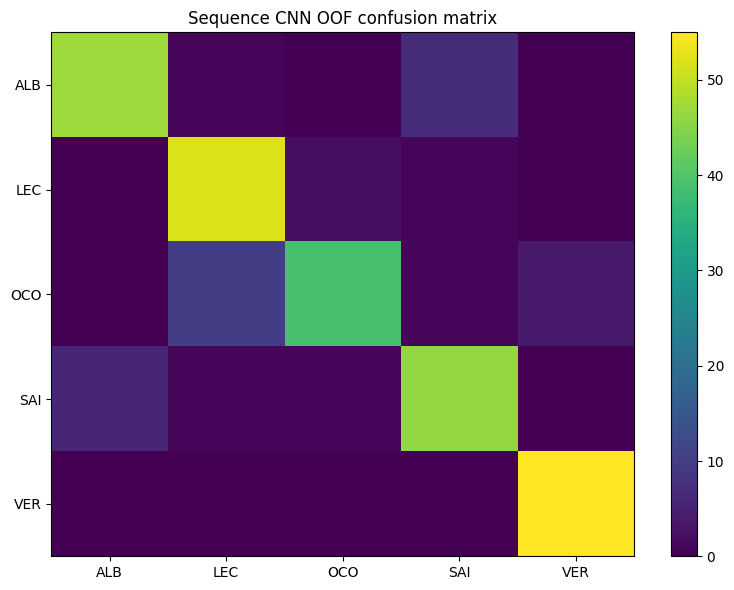

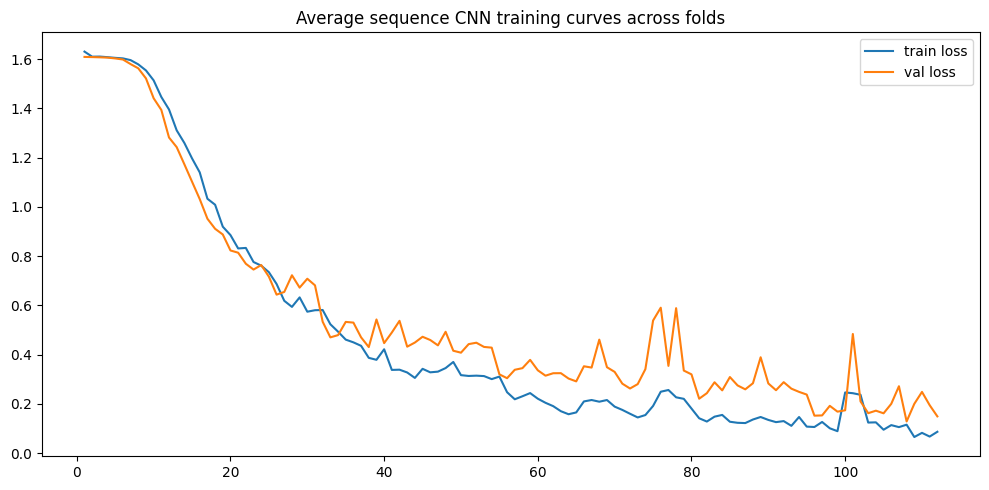

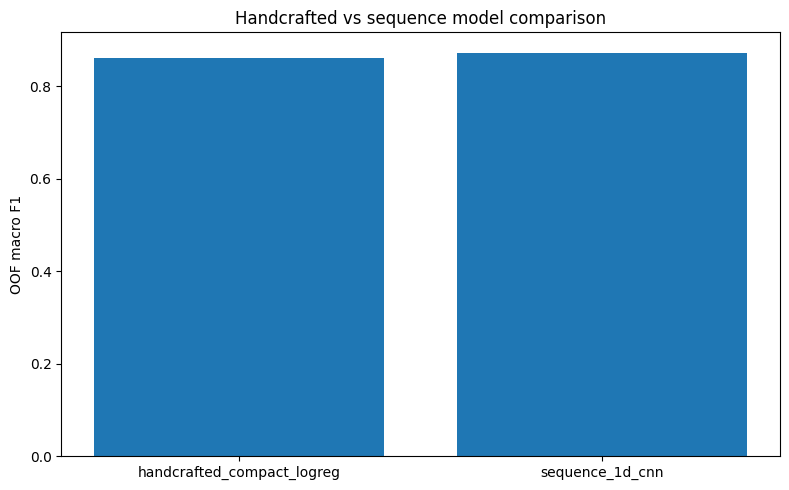

In [7]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_df, aspect="auto")
plt.xticks(range(len(labels)), labels)
plt.yticks(range(len(labels)), labels)
plt.colorbar()
plt.title("Sequence CNN OOF confusion matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
history_plot_df = sequence_cnn_history_df.groupby("epoch").agg(loss=("loss", "mean"), val_loss=("val_loss", "mean")).reset_index()
plt.plot(history_plot_df["epoch"], history_plot_df["loss"], label="train loss")
plt.plot(history_plot_df["epoch"], history_plot_df["val_loss"], label="val loss")
plt.legend()
plt.title("Average sequence CNN training curves across folds")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(comparison_df["model_family"], comparison_df["oof_macro_f1"])
plt.title("Handcrafted vs sequence model comparison")
plt.ylabel("OOF macro F1")
plt.tight_layout()
plt.show()

## Interpretation Notes

- If the sequence model underperforms the compact handcrafted model, that does not mean sequence information is useless; it may simply mean the first architecture is too simple or data-hungry.
- If it performs similarly, that is already a meaningful result because it shows the raw telemetry sequence itself contains comparable driver signal.
- The fairest next refinement after this notebook would be a stronger sequence architecture or a self-supervised sequence representation, still on the same driver subset.